In [1]:
using Oceananigans

In [ ]:
using TopographicHorizontalConvection: HorizontalConvectionSimulation

In [26]:
using TopographicHorizontalConvection:dissipation_analysis
using TopographicHorizontalConvection:plot_normalized
using TopographicHorizontalConvection:plot_avg
using TopographicHorizontalConvection:diss_norm_eq_subplots
using TopographicHorizontalConvection:get_ψ

In [1]:
simulation = HorizontalConvectionSimulation(Ra=1e7, h₀_frac=0.6, numhill = 1, Nx=535, Ny=1, Nz=67, b_init=-0.6, advection=true, architecture=CPU())

Simulation of NonhydrostaticModel{CPU, ImmersedBoundaryGrid}(time = 0 seconds, iteration = 0)
├── Next time step: 12.217 ms
├── Elapsed wall time: 0 seconds
├── Wall time per iteration: NaN days
├── Stop time: 52.705 minutes
├── Stop iteration : Inf
├── Wall time limit: Inf
├── Callbacks: OrderedDict with 6 entries:
│   ├── stop_time_exceeded => Callback of stop_time_exceeded on IterationInterval(1)
│   ├── stop_iteration_exceeded => Callback of stop_iteration_exceeded on IterationInterval(1)
│   ├── wall_time_limit_exceeded => Callback of wall_time_limit_exceeded on IterationInterval(1)
│   ├── nan_checker => Callback of NaNChecker for u on IterationInterval(100)
│   ├── wizard => Callback of TimeStepWizard(cfl=0.5, max_Δt=Inf, min_Δt=0.0) on IterationInterval(50)
│   └── progress => Callback of (::TopographicHorizontalConvection.var"#progress#9") on IterationInterval(10)
├── Output writers: OrderedDict with 6 entries:
│   ├── checkpointer => Checkpointer{TimeInterval, Vector{Symbol}}

In [11]:
#import the data here so I dont have to run all the turbulent_convection_hills_section_snapshots

ds0_o = NCDataset(string("/Users/hfdrake/code/HorizontalConvection/output/turbulent_flat_0_Ra100000.0_coldstart/oceanostics.nc"));
ds1_o = NCDataset(string("/Users/hfdrake/code/output/turbulent_h0_Ra1.0e6_coldstart_oceanostics.nc"));
ds2_o = NCDataset(string("/Users/hfdrake/code/output/turbulent_flat_0.6_Ra5.0e6_coldstart_oceanostics.nc"));
ds3_o = NCDataset(string("/Users/hfdrake/code/HorizontalConvection/output/turbulent_flat_0_Ra1.0e7_coldstart/oceanostics.nc"));

list_of_datasets = [ds0_o, ds1_o, ds2_o, ds3_o]


#hills

ds_h0_o = NCDataset(string("/Users/hfdrake/code/HorizontalConvection/output/turbulent_onehill_0.6_Ra100000.0_coldstart_oceanostics.nc"));
ds_h1_o = NCDataset(string("/Users/hfdrake/code/HorizontalConvection/output/turbulent_onehill_0.6_Ra1.0e6_coldstart_oceanostics.nc"));
ds_h2_o = NCDataset(string("/Users/hfdrake/code/HorizontalConvection/output/turbulent_onehill_0.6_Ra5.0e6_coldstart_oceanostics.nc"));
ds_h3_o = NCDataset(string("/Users/hfdrake/code/HorizontalConvection/output/turbulent_onehill_0.6_Ra1.0e7_coldstart_oceanostics.nc"));

list_hill_datasets = [ds_h0_o, ds_h1_o, ds_h2_o, ds_h3_o];

In [12]:
ds0 = NCDataset(string("/Users/hfdrake/code/HorizontalConvection/output/turbulent_flat_0_Ra100000.0_coldstart/buoyancy.nc"));
ds1 = NCDataset(string("/Users/hfdrake/code/output/turbulent_h0_Ra1.0e6_coldstart_buoyancy.nc"));
ds2 = NCDataset(string("/Users/hfdrake/code/output/turbulent_flat_0.6_Ra5.0e6_coldstart_buoyancy.nc"));
ds3 = NCDataset(string("/Users/hfdrake/code/HorizontalConvection/output/turbulent_flat_0_Ra1.0e7_coldstart/buoyancy.nc"));

list_ds_buoy = [ds0, ds1, ds2, ds3];


ds_h0 = NCDataset(string("/Users/hfdrake/code/HorizontalConvection/output/turbulent_onehill_0.6_Ra100000.0_coldstart_buoyancy.nc"));
ds_h1 = NCDataset(string("/Users/hfdrake/code/HorizontalConvection/output/turbulent_onehill_0.6_Ra1.0e6_coldstart_buoyancy.nc"));
ds_h2 = NCDataset(string("/Users/hfdrake/code/HorizontalConvection/output/turbulent_onehill_0.6_Ra5.0e6_coldstart_buoyancy.nc"));
ds_h3 = NCDataset(string("/Users/hfdrake/code/HorizontalConvection/output/turbulent_onehill_0.6_Ra1.0e7_coldstart_buoyancy.nc"));

list_hill_ds_buoy = [ds_h0, ds_h1, ds_h2, ds_h3];

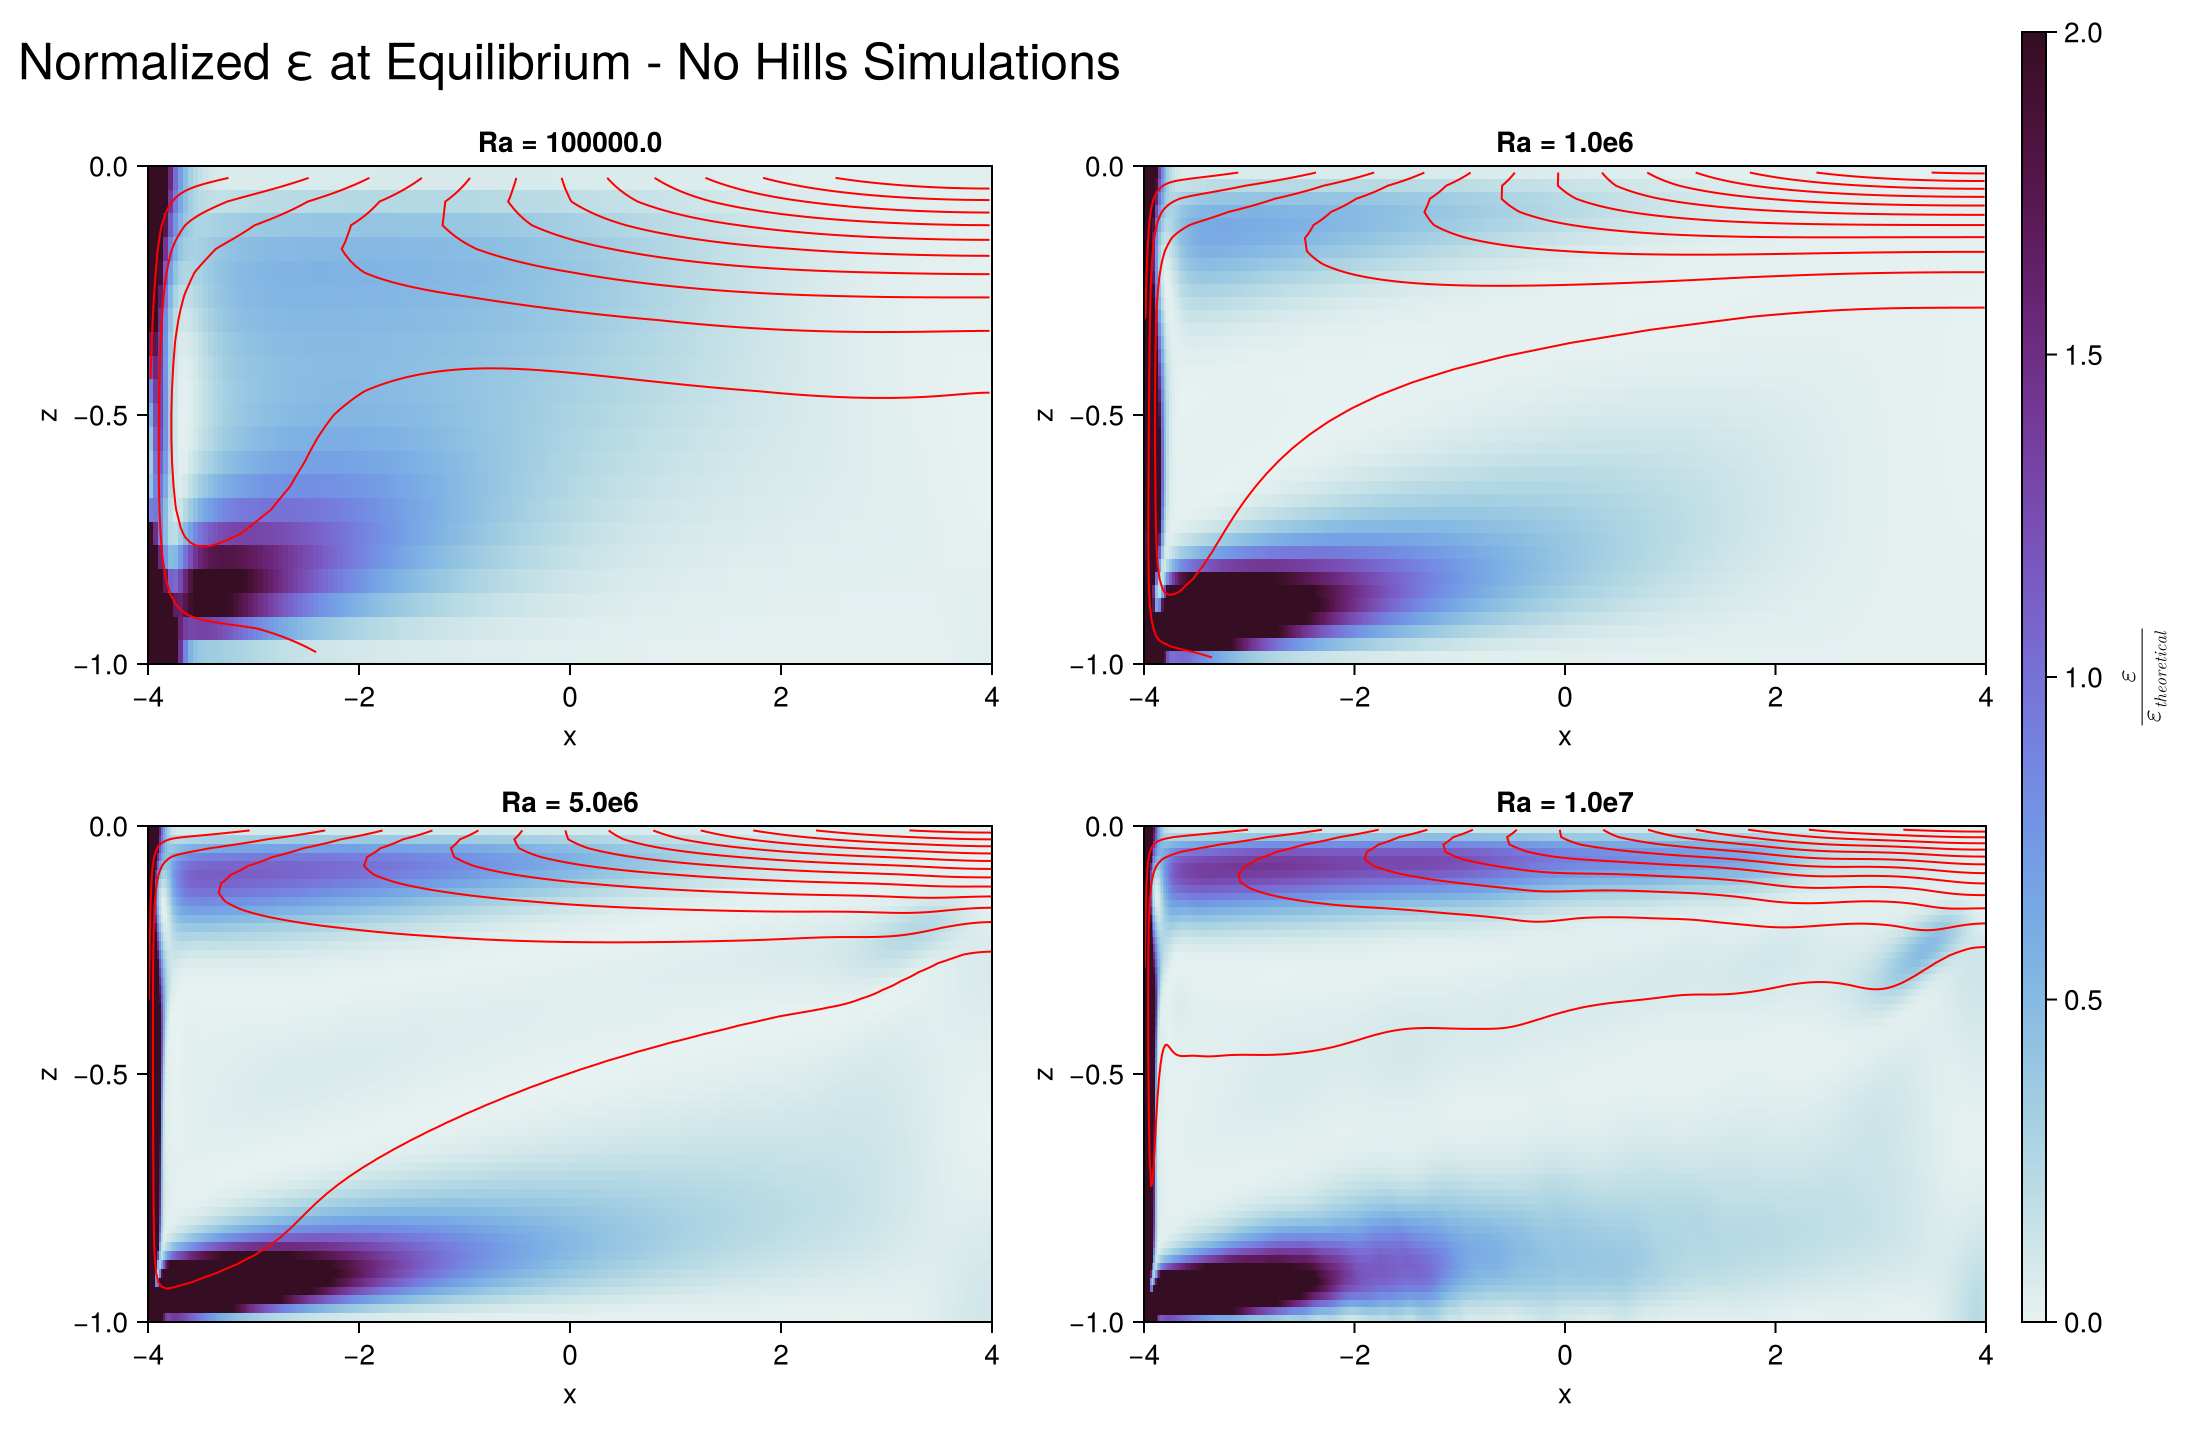

In [5]:
# Create subplots for all no-hill datasets
fig_no_hills = diss_norm_eq_subplots(list_of_datasets, list_ds_buoy, "ε", (0,2), cols=2, 
        main_title="Normalized ε at Equilibrium - No Hills Simulations")
fig_no_hills

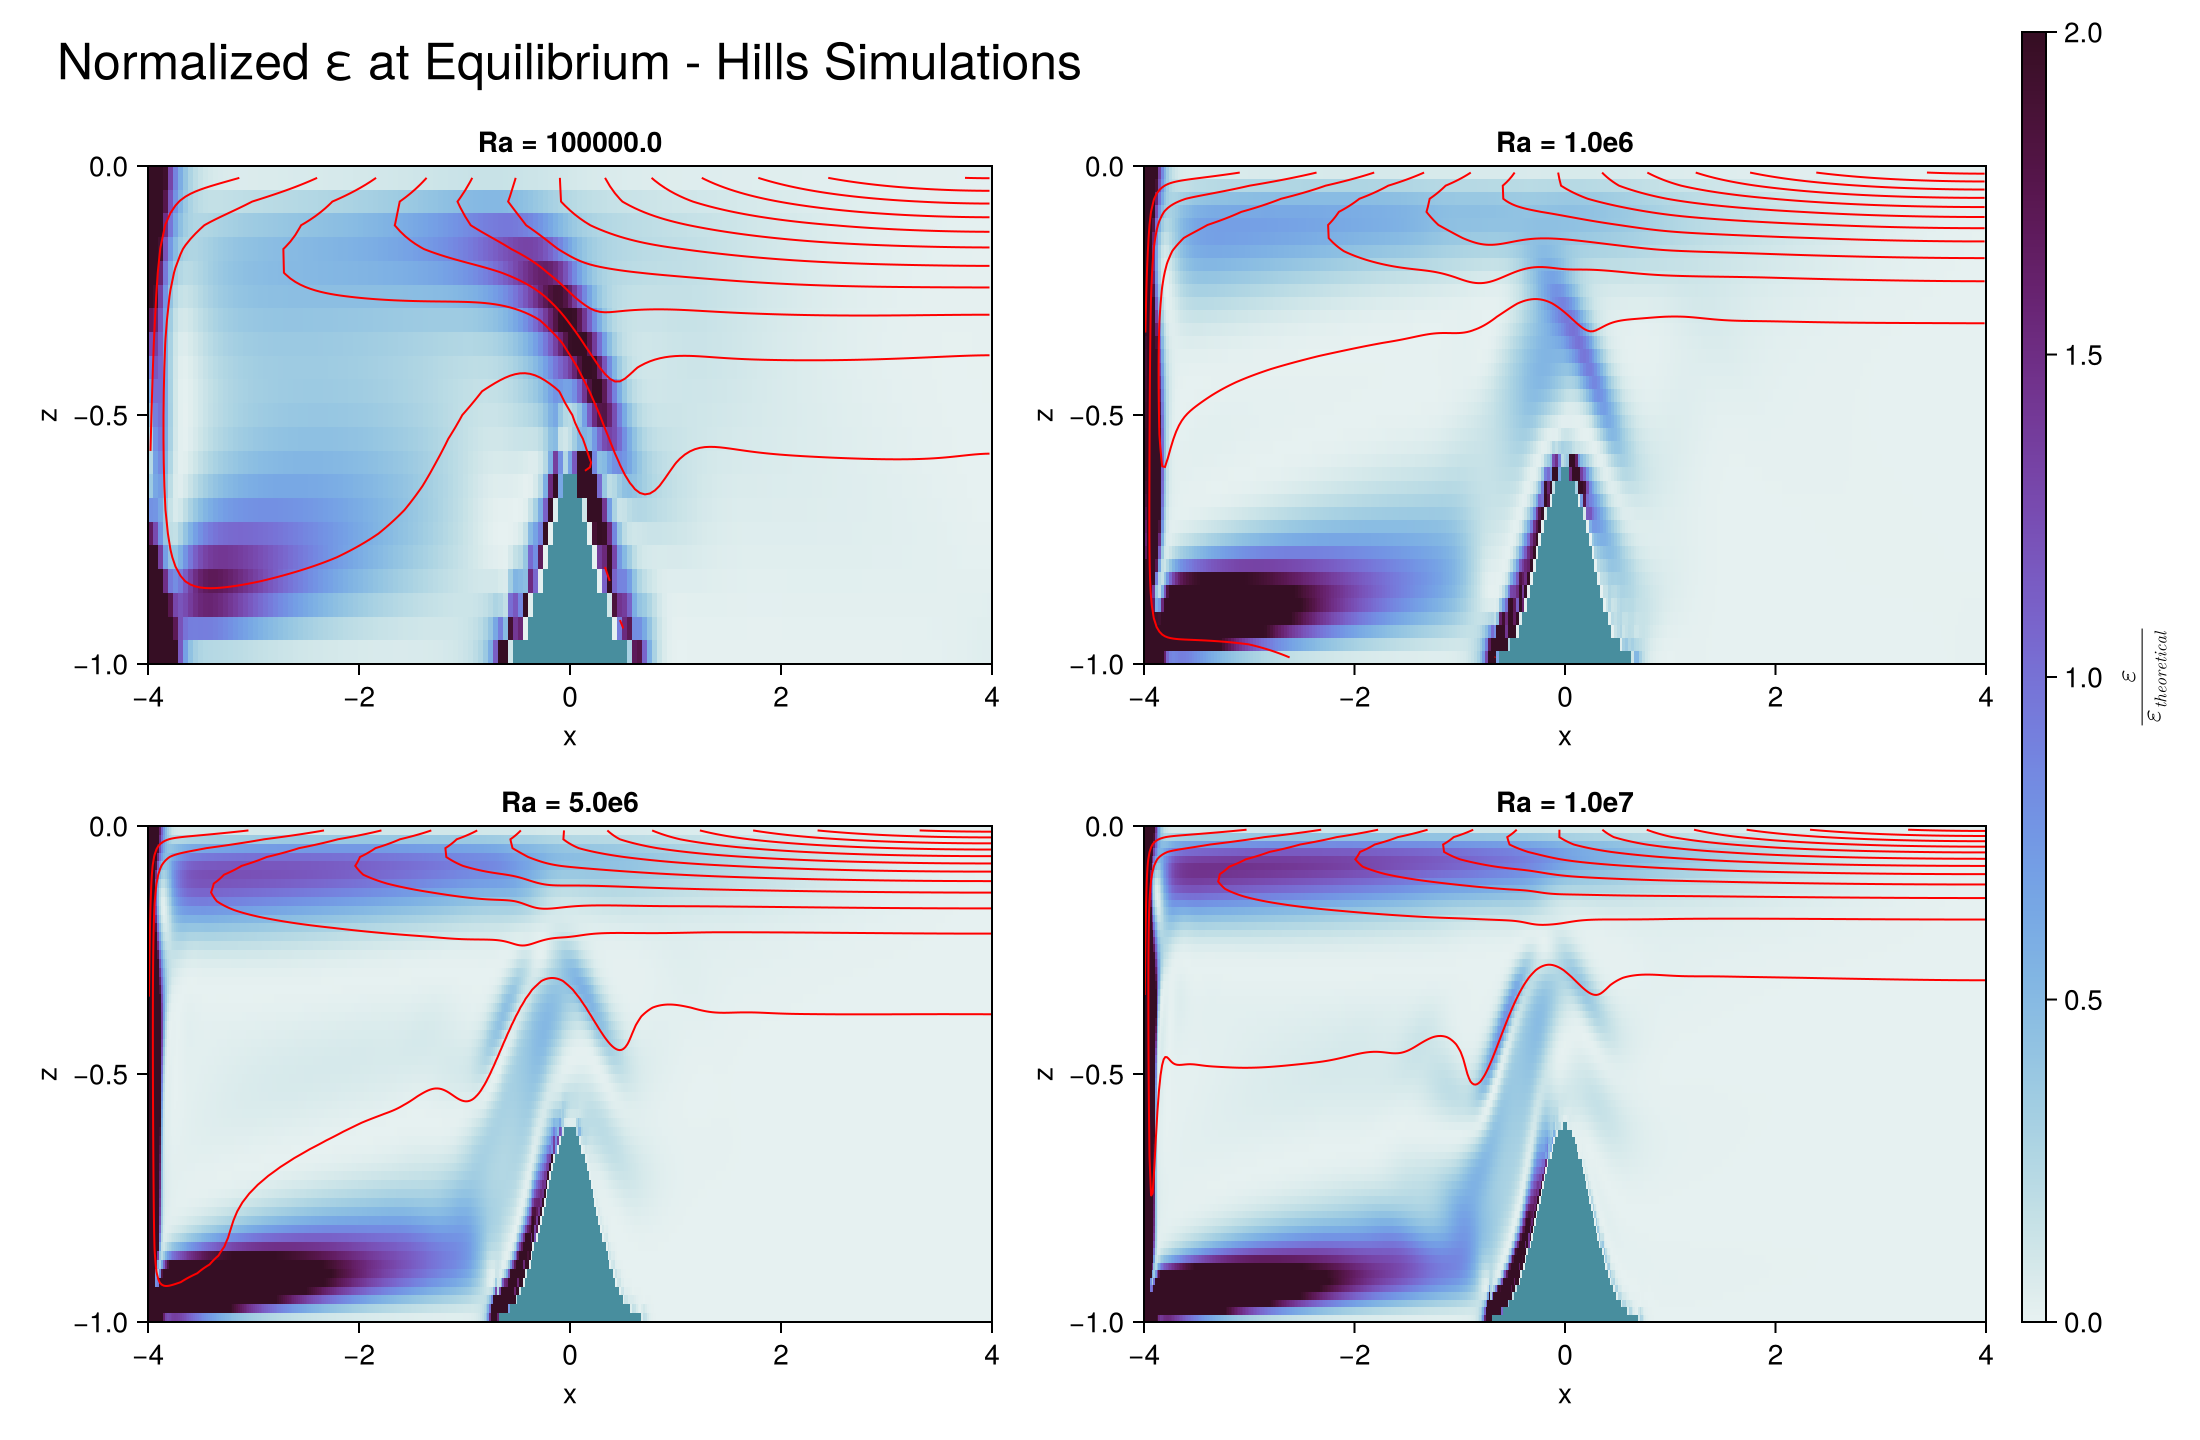

In [6]:
fig_hills = diss_norm_eq_subplots(list_hill_datasets, list_hill_ds_buoy, "ε", (0,2), cols=2, 
        main_title="Normalized ε at Equilibrium - Hills Simulations")
fig_hills

In [12]:
ε_theory_2, ε_avg_2, ε_mean_2 = ε_analysis(ds2_o);

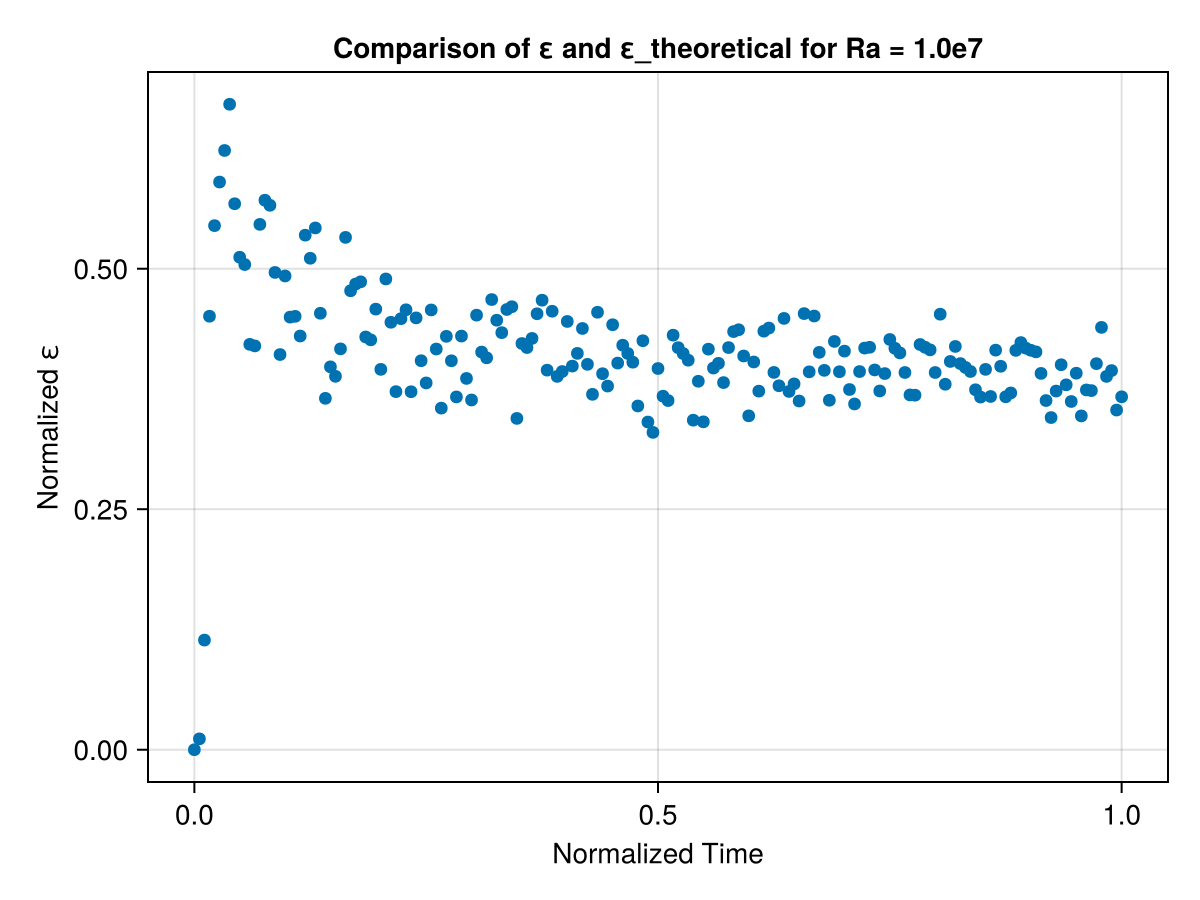

In [13]:
f2 = plot_ε_normalized(ds2_o)

In [94]:
#equilibrium ε plot
function ε_norm_eq_plot(ds, CR)
    ε = ds["ε"][4+1:end-4, 1, 4+1:end-4, :]
    Ra = ds.attrib["Ra"]
    time = ds["time"][:]
    #print(size(time))
    x = ds["xC"][4+1:end-4]
    z = ds["zC"][4+1:end-4]
    equilibrium_start = round(Int, 0.9 * size(time, 1))
    time_eq_start = time[equilibrium_start]
    ε_eq = ε[:, :, equilibrium_start]
    ε_theory = ε_analysis(ds)[1]
    ε_norm = ε_eq ./ ε_theory

    fig = Figure(size=(800, 400))
    ax = Axis(fig[1, 1], aspect =8, 
            xlabel="x", ylabel="z", 
            title = "Normalized ε of Ra = $Ra Simulation at Equilibrium Time")
    hm = heatmap!(ax, x, z, ε_norm, colorrange = CR ,colormap=:viridis)
    Colorbar(fig[1, 2], hm, label=L"ε/ε_{crit}")

    return fig
end


(185,)166

0.0006324555320336759

Below is the animation and similar analysis plot for Ra=5e6

<video width="600" height="400" controls>
    <source src="/Users/hfdrake/code/HorizontalConvection/animations/nohills5e6.mp4" type "video/mp4">
</video>

In [19]:
ds2_b = NCDataset(string("/Users/hfdrake/code/HorizontalConvection/output/turbulent_h0_Ra5.0e6_coldstart_buoyancy.nc"));
ds2_o = NCDataset(string("/Users/hfdrake/code/HorizontalConvection/output/turbulent_h0_Ra5.0e6_coldstart_oceanostics.nc"));

In [15]:
ε_theory_3, ε_avg_3, ε_mean_3 = ε_analysis(ds3_o);

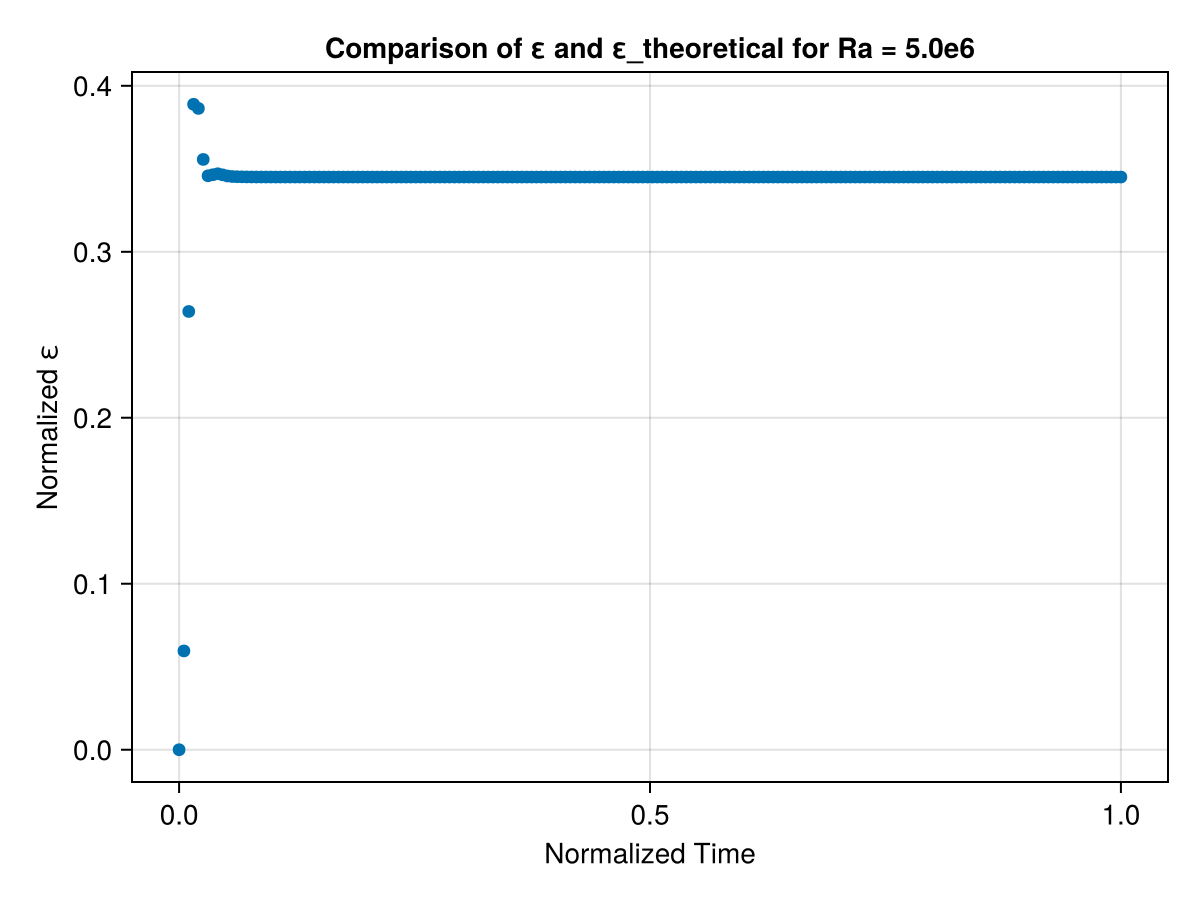

In [16]:
f3 = plot_ε_normalized(ds3_o)

f3

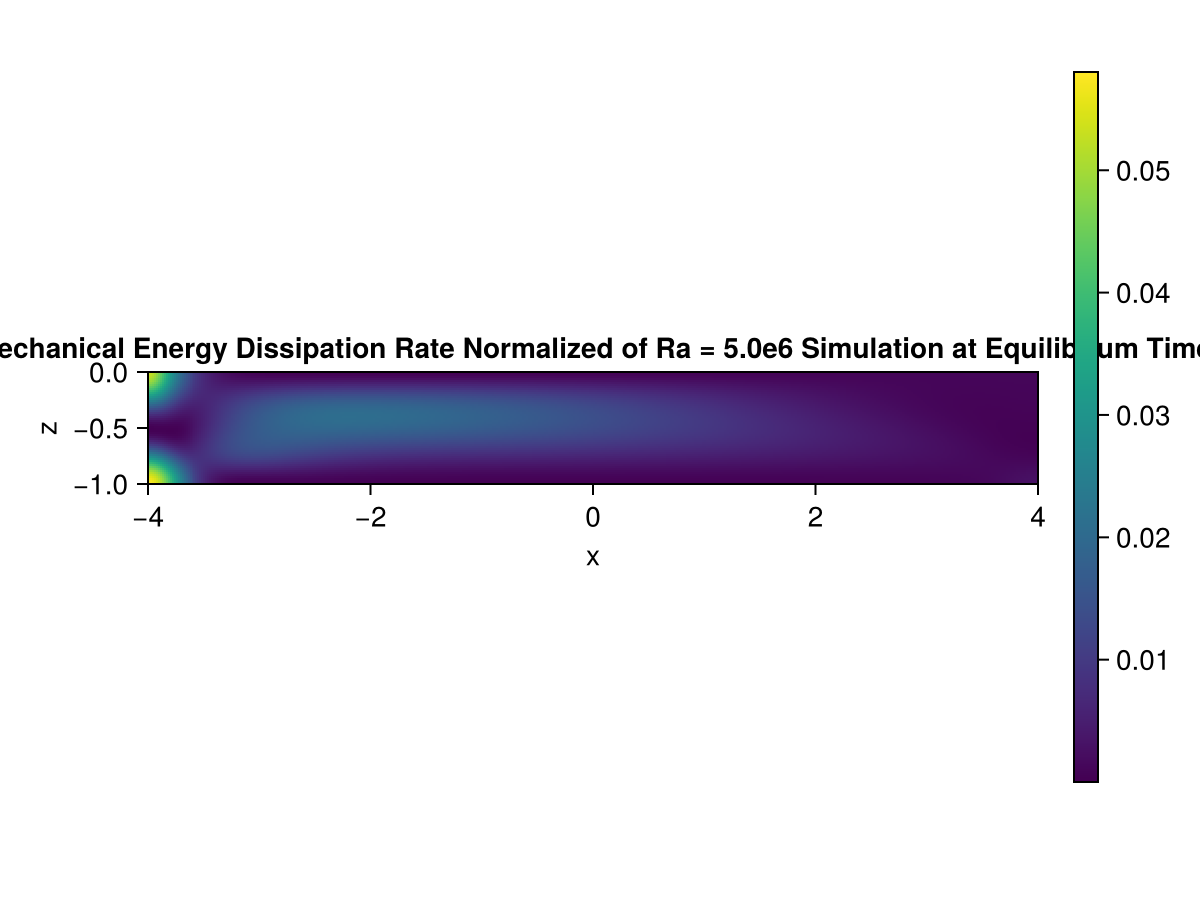

In [64]:
#equilibrium ε plot

fig4 = plot_ε_equilibrium(ds3_o)

NOW for the hills simulations

we start with Ra=1e5

<video width="600" height="400" controls>
    <source src="/Users/hfdrake/code/HorizontalConvection/animations/onehill1e5.mp4" type "video/mp4">
</video>

In [18]:
sqrt(1/1e7)

0.00031622776601683794

κ: 3.16e-03, ν: 3.16e-03
for loops in jupyter are scuffed as hell
κ: 1.00e-03, ν: 1.00e-03

κ: 1.00e-03, ν: 1.00e-03
for loops in jupyter are scuffed as hell
κ: 4.47e-04, ν: 4.47e-04
for loops in jupyter are scuffed as hell
κ: 3.16e-04, ν: 3.16e-04
for loops in jupyter are scuffed as hell
for loops in jupyter are scuffed as hell
κ: 4.47e-04, ν: 4.47e-04
for loops in jupyter are scuffed as hell
κ: 3.16e-04, ν: 3.16e-04
for loops in jupyter are scuffed as hell


κ: 3.16e-03, ν: 3.16e-03
for loops in jupyter are scuffed as hell
κ: 1.00e-03, ν: 1.00e-03

κ: 1.00e-03, ν: 1.00e-03
for loops in jupyter are scuffed as hell
κ: 4.47e-04, ν: 4.47e-04
for loops in jupyter are scuffed as hell
κ: 3.16e-04, ν: 3.16e-04
for loops in jupyter are scuffed as hell
for loops in jupyter are scuffed as hell
κ: 4.47e-04, ν: 4.47e-04
for loops in jupyter are scuffed as hell
κ: 3.16e-04, ν: 3.16e-04
for loops in jupyter are scuffed as hell


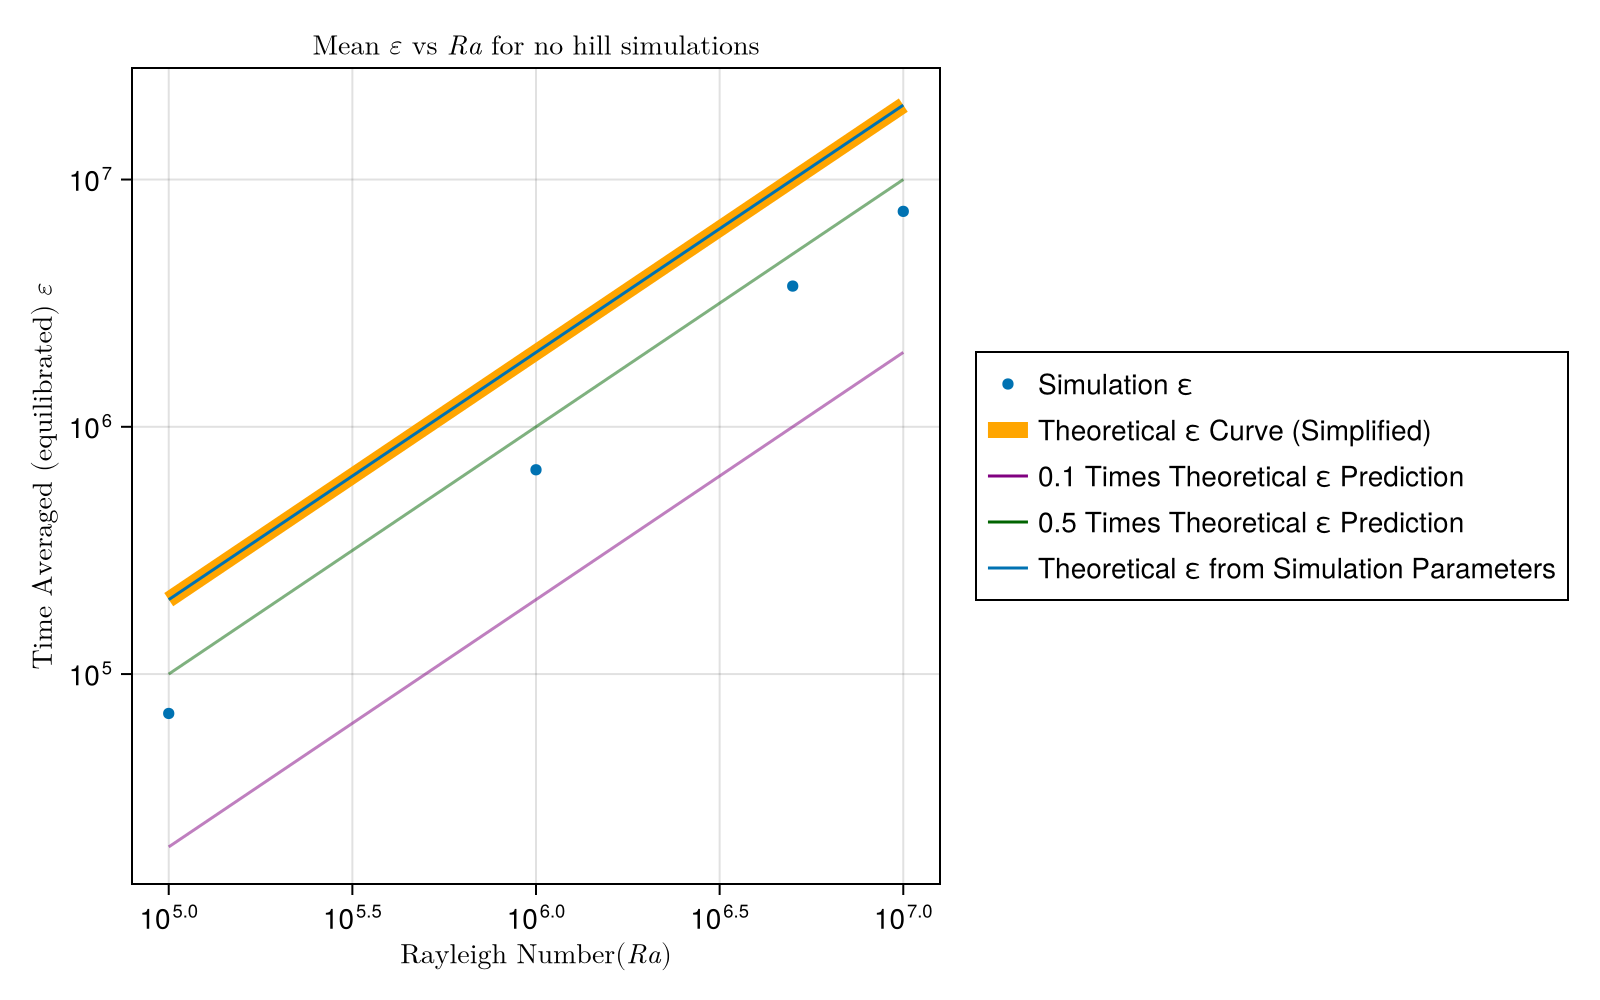

In [21]:
ds_h0_b = NCDataset(string("/Users/hfdrake/code/HorizontalConvection/output/turbulent_onehill_0.6_Ra100000.0_coldstart_buoyancy.nc"));
ds_h0_o = NCDataset(string("/Users/hfdrake/code/HorizontalConvection/output/turbulent_onehill_0.6_Ra100000.0_coldstart_oceanostics.nc"));

In [33]:
x = ds["xC"][4+1:end-4]; Nx = length(x);
z = ds["zC"][4+1:end-4]; Nz = length(z);
time = ds["time"][:];
Δx = reshape(diff(ds["xF"])[4+1:end-4], Nx,1,1);
Δz = reshape(diff(ds["zF"])[4+1:end-4], 1,1,Nz);
ΔA = Δx; #flat in y -- 2 dimensional
ΔV = ΔA.*Δz;
var_array = zeros(size(time,1));
for n in 1:size(time, 1)
    var_t = ds["ε"][4+1:end-4, :, 4+1:end-4, n]
    wet = var_t.!=0.
    var_t[.!wet] .= NaN
    var_array[n] = nansum(
        var_t .*
        ΔV,
        dims=(1,2,3)
    )[1,1,1]
end

In [69]:
ε_t = ds["ε"][4+1:end-4, :, 4+1:end-4, 4];
wet = ε_t.!=0.

size(ΔV)

(169, 1, 21)

Ra: 100000.0
Ra: 1.0e6
Ra: 5.0e6
Ra: 1.0e6
Ra: 5.0e6
Ra: 1.0e7

Ra: 1.0e7


Ra: 100000.0
Ra: 1.0e6
Ra: 5.0e6
Ra: 1.0e6
Ra: 5.0e6
Ra: 1.0e7

Ra: 1.0e7


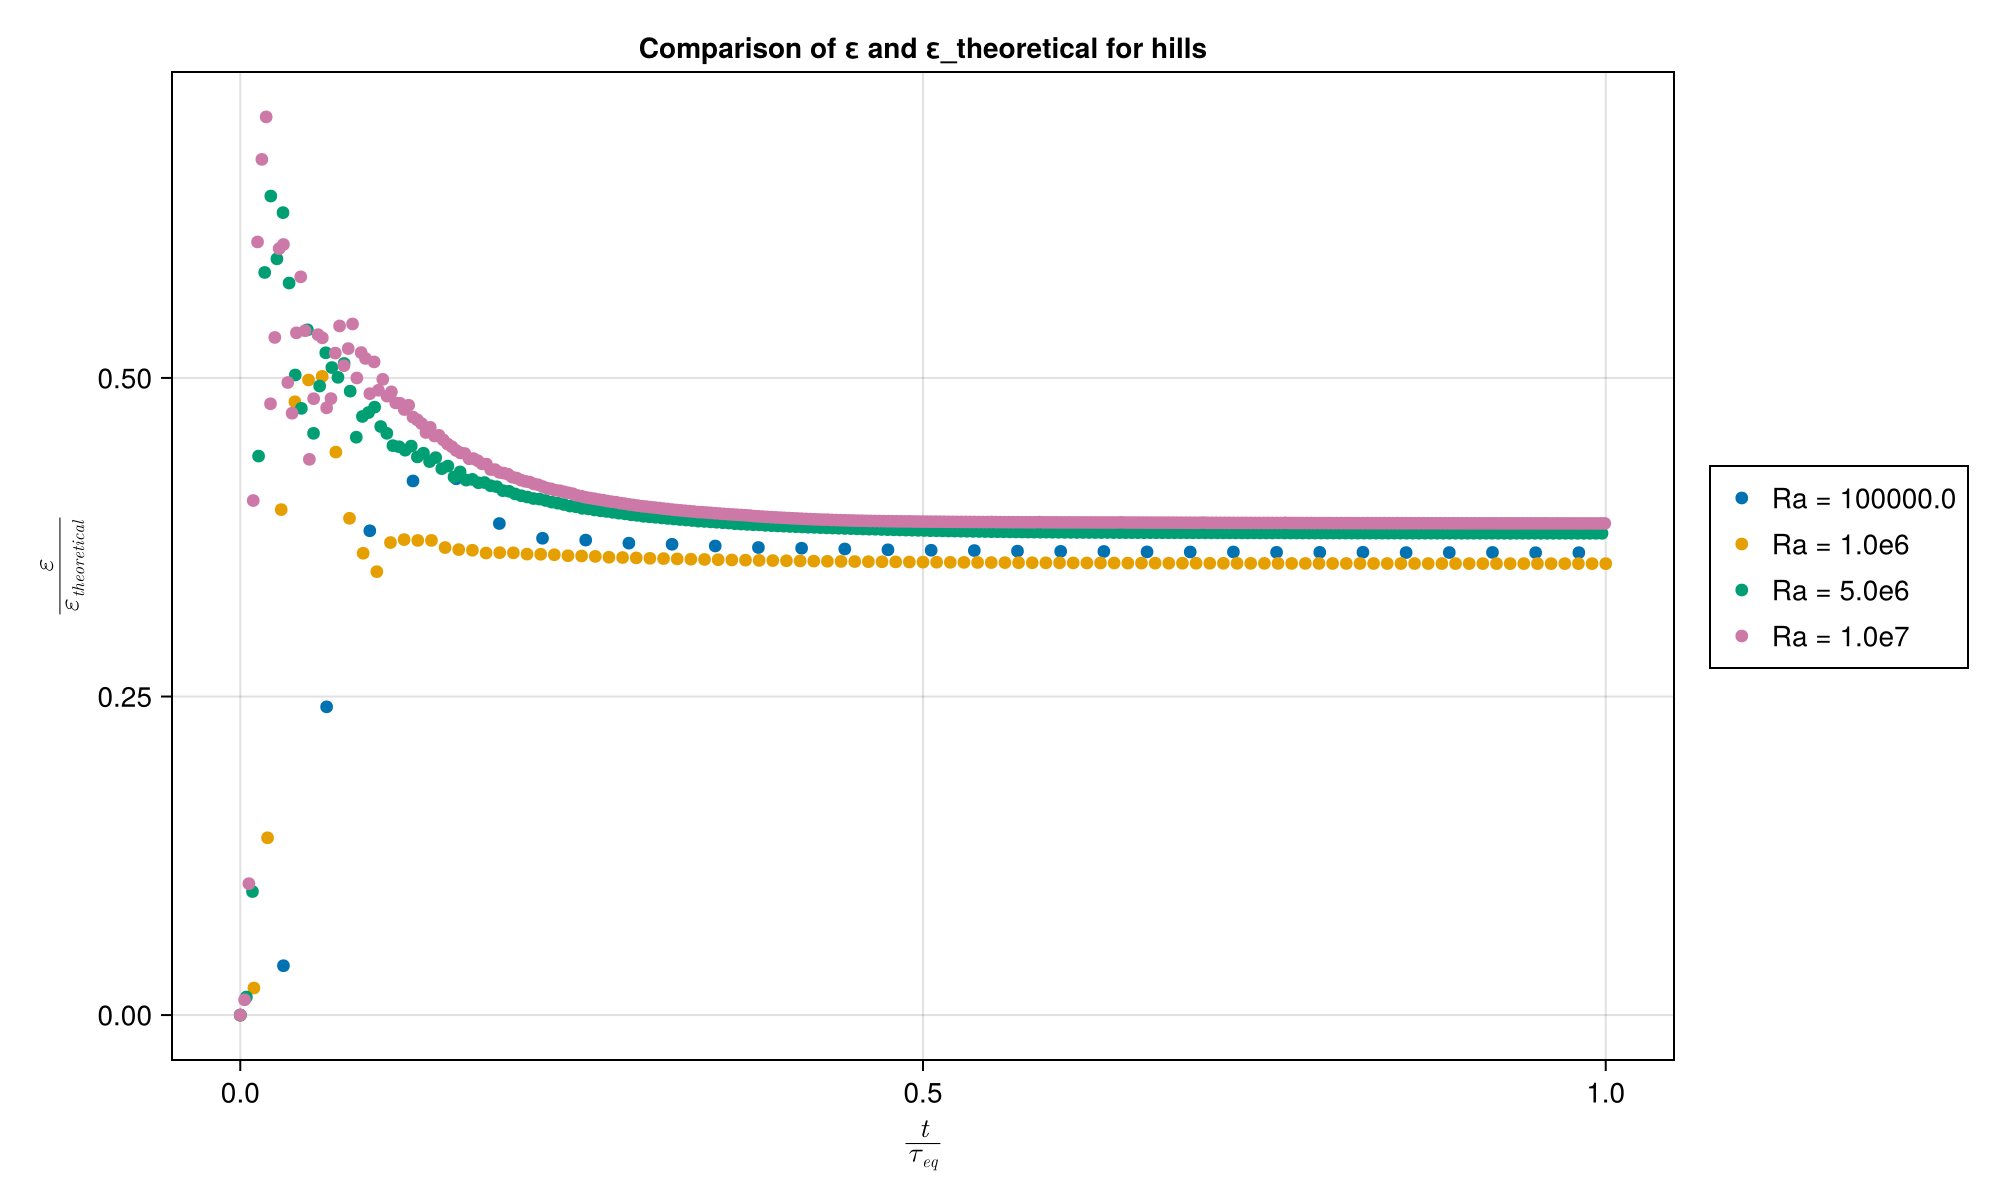

In [25]:
ff = Figure()
ax = Axis(ff[1, 1])
hm = heatmap!(ax, wet[:, 1, :])
Colorbar(ff[1, 2], hm)
ff

below is Ra=1e6 with one hill

<video width="600" height="400" controls>
    <source src="/Users/hfdrake/code/HorizontalConvection/animations/onehill1e6.mp4" type "video/mp4">
</video>

We want to repeat this analysis for $\chi$, the volume averaged dissipation rate of buoyancy varience: $\chi = \kappa \langle |\nabla b|^2 \rangle$.

From Winters and Young (2009) the bound on $\chi$ for horizontal convection is set as:
$$ \chi \leq 4.57 \frac{k^{1/3}b_{max}^{7/3}}{Pr^{1/3}H} $$ 
we have to modify this expression slightly because Winters and Young's set up has $b_{min} =0$ at the surface. Our experiment has $b_{max} = 1$ and $b_{min}=-1$ since we impose a sinusodial function for the buoyancy forcing at the surface. 

$$ \chi \leq 4.57 \frac{\kappa^{1/3} (2 b_{\bigstar})^{7/3}}{{Pr}^{1/3}H} $$

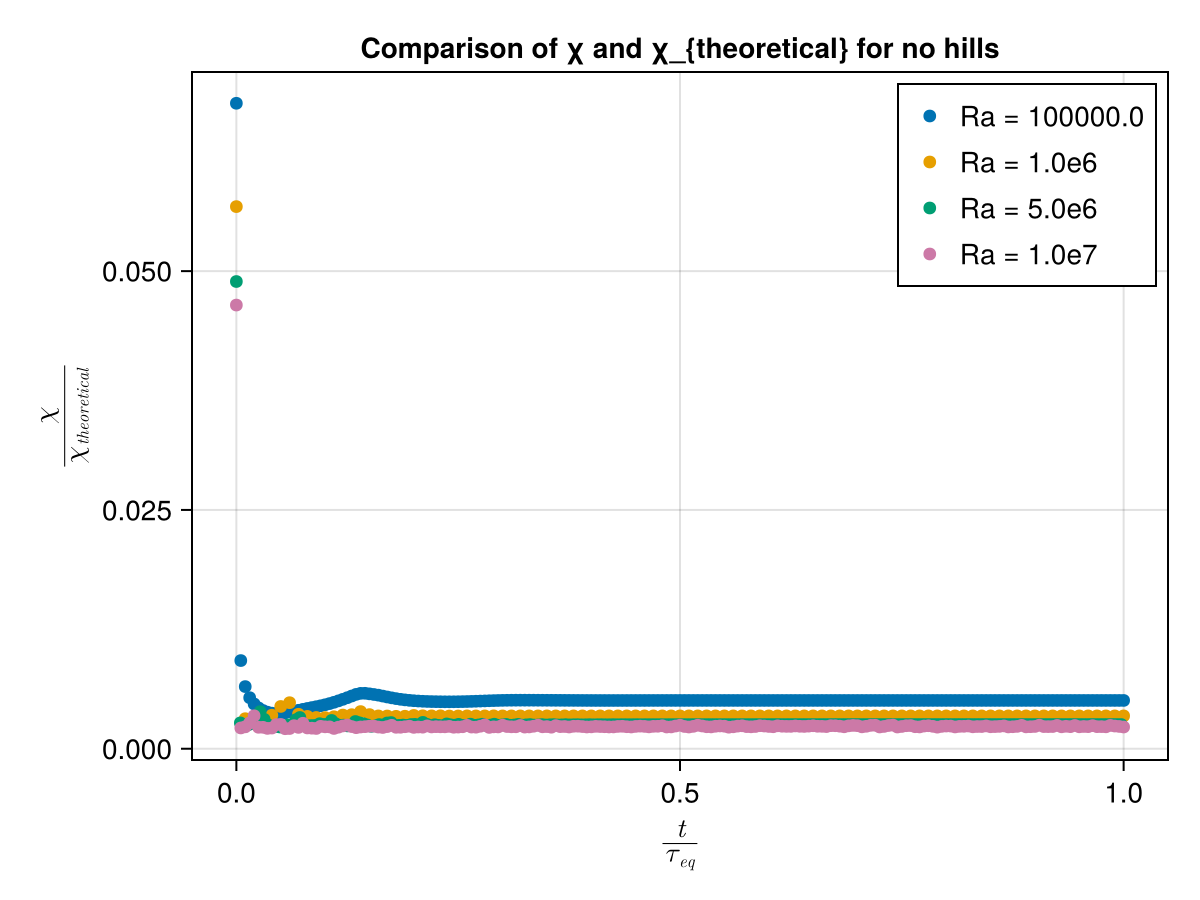

In [24]:
f_χ = Figure()
ax = Axis(f_χ[1, 1], xlabel=L"\frac{t}{\tau_{eq}}", ylabel=L"\frac{χ}{χ_{theoretical}}", title="Comparison of χ and χ_{theoretical} for no hills")
for ds in list_of_datasets
    plot_normalized(ax, ds, "χ")
end

axislegend(ax)
f_χ

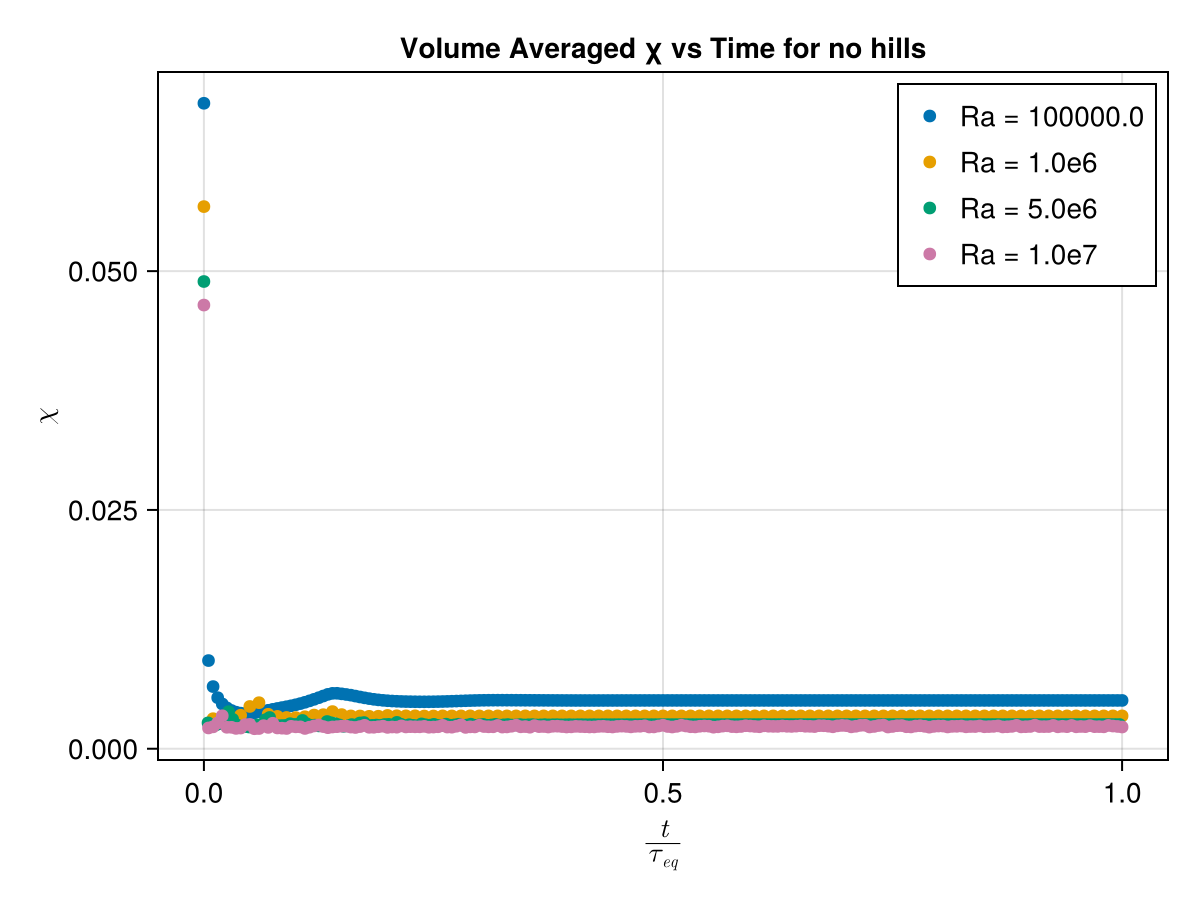

In [26]:
f_χ_2 = Figure()
ax_χ_2 = Axis(f_χ_2[1, 1], xlabel=L"\frac{t}{\tau_{eq}}", ylabel=L"χ", title="Volume Averaged χ vs Time for no hills")
for ds in list_of_datasets
    plot_normalized(ax_χ_2, ds, "χ")
end
axislegend(ax_χ_2)
f_χ_2

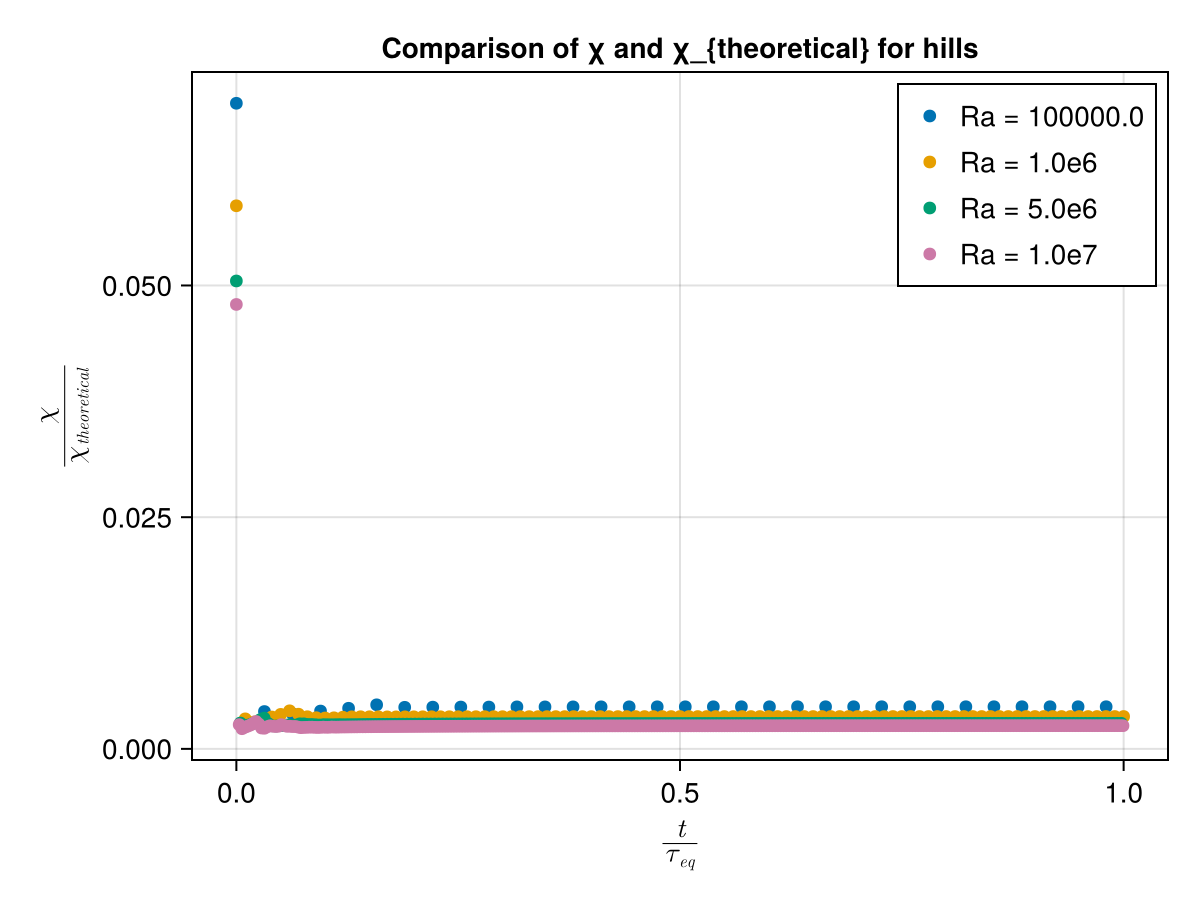

In [27]:
f_χ_hill = Figure()
ax_χ_hill = Axis(f_χ_hill[1, 1], xlabel=L"\frac{t}{\tau_{eq}}", ylabel=L"\frac{χ}{χ_{theoretical}}", title="Comparison of χ and χ_{theoretical} for hills")
for ds in list_hill_datasets
    plot_normalized(ax_χ_hill, ds, "χ")
end
axislegend(ax_χ_hill)
f_χ_hill

diss_norm_eq_subplots (generic function with 1 method)

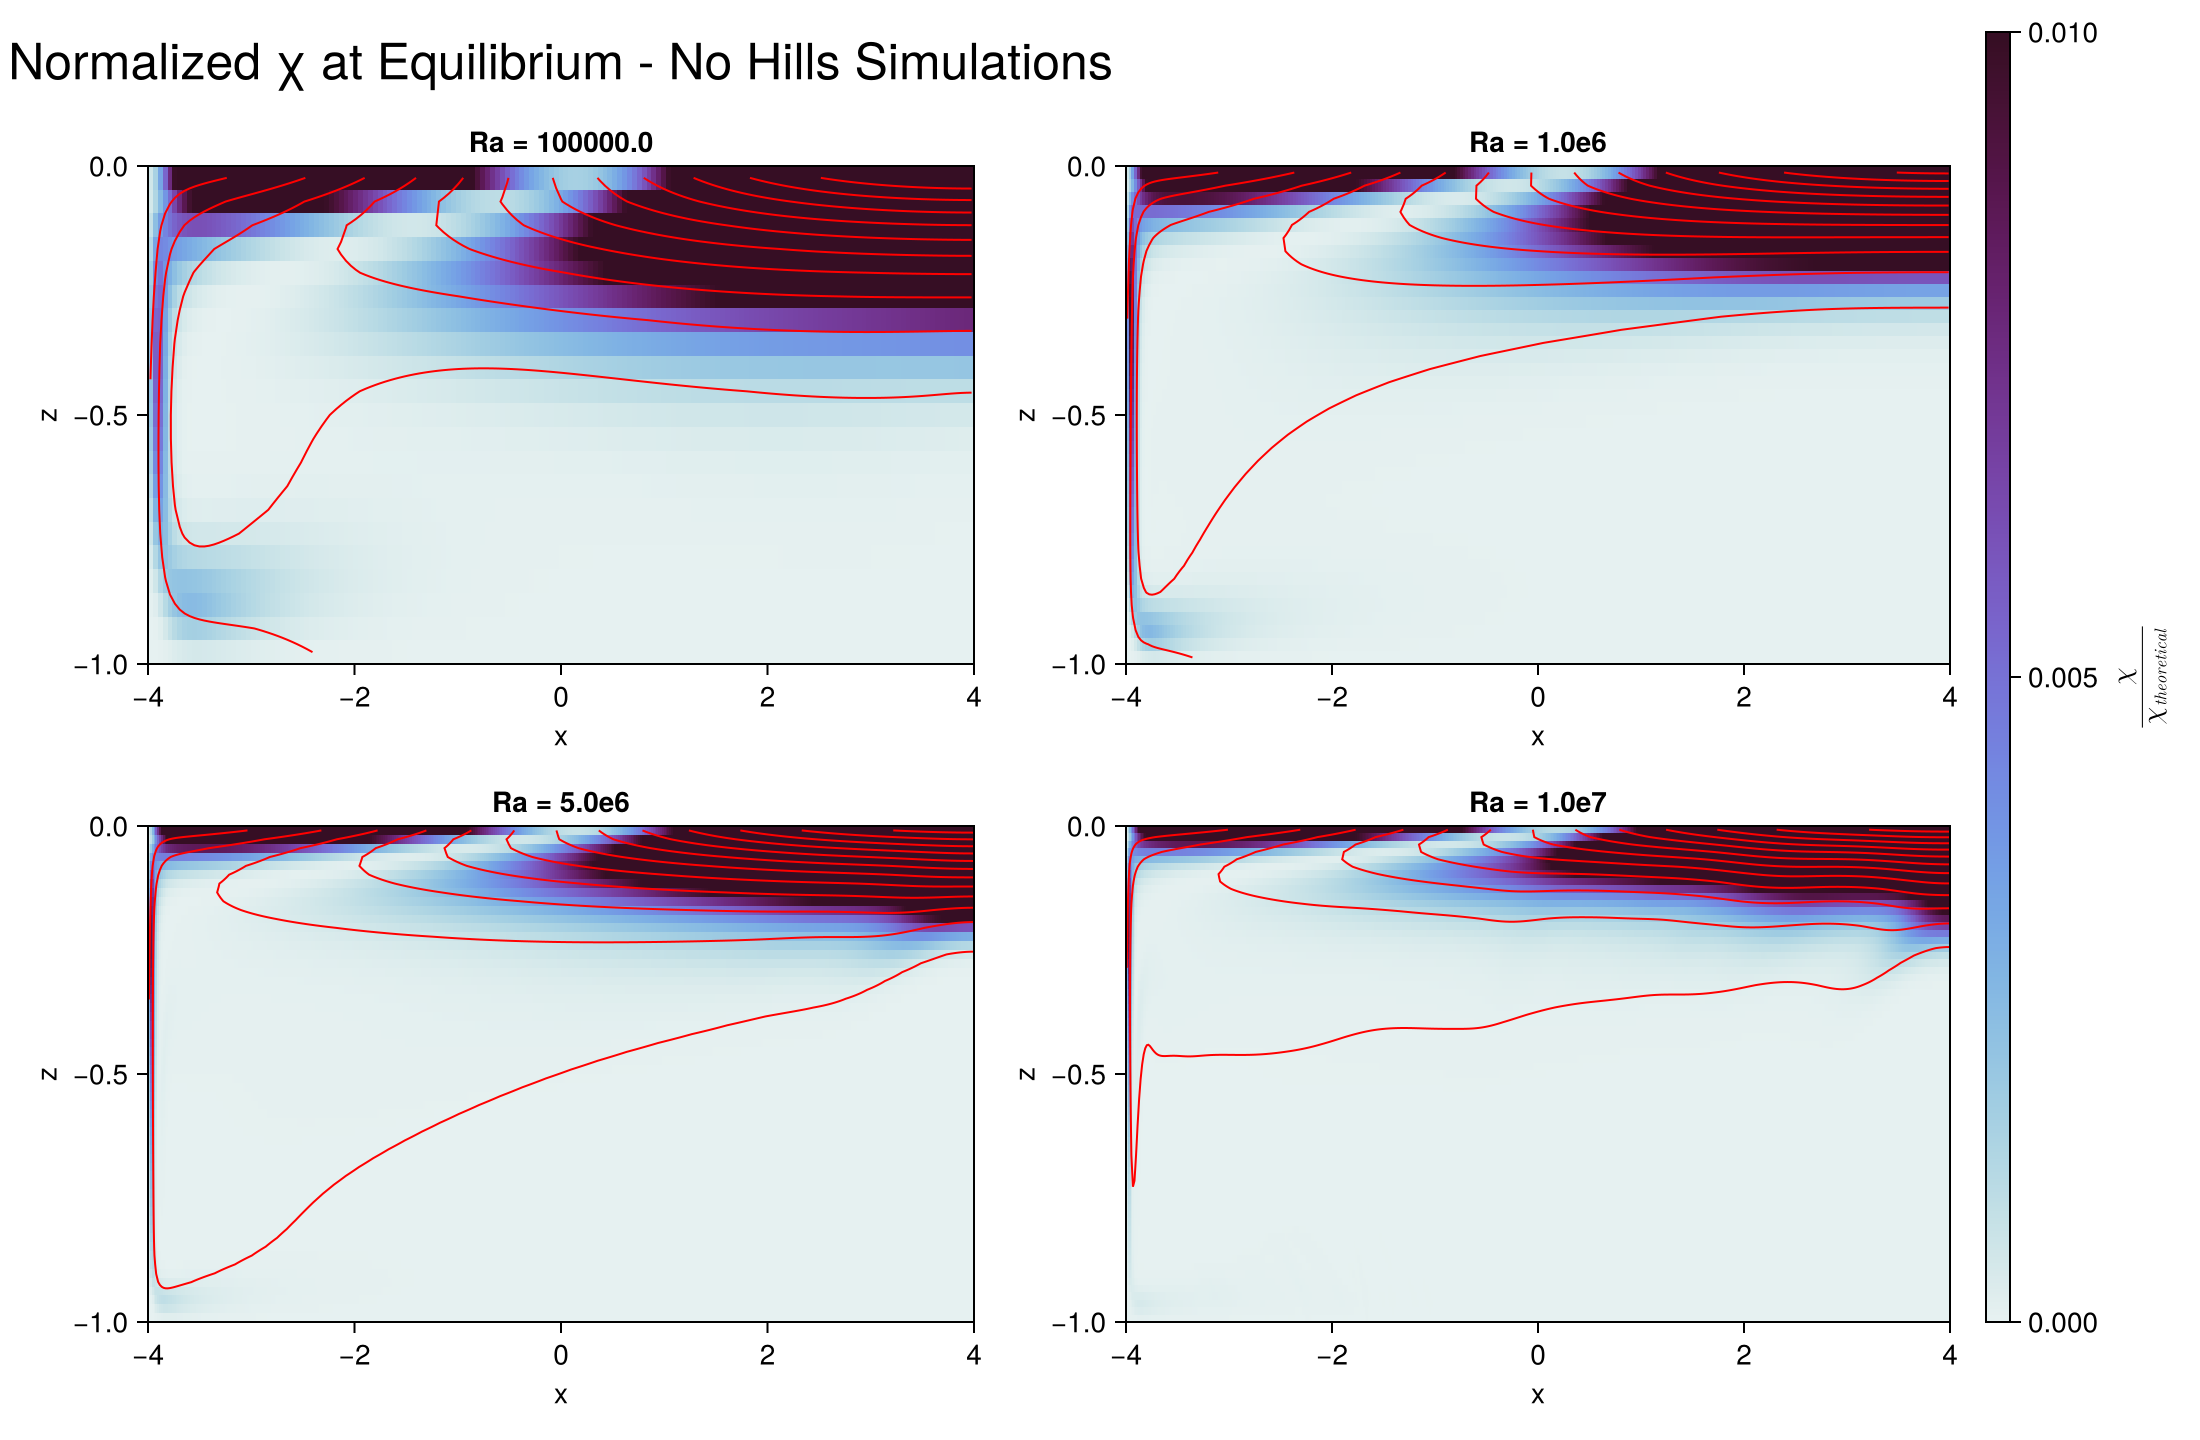

In [7]:
#create heatmaps for χ no hills simulations
χ_hm_no_hills = diss_norm_eq_subplots(list_of_datasets, list_ds_buoy, "χ", (0, 0.01), cols=2, 
        main_title="Normalized χ at Equilibrium - No Hills Simulations")

χ_hm_no_hills

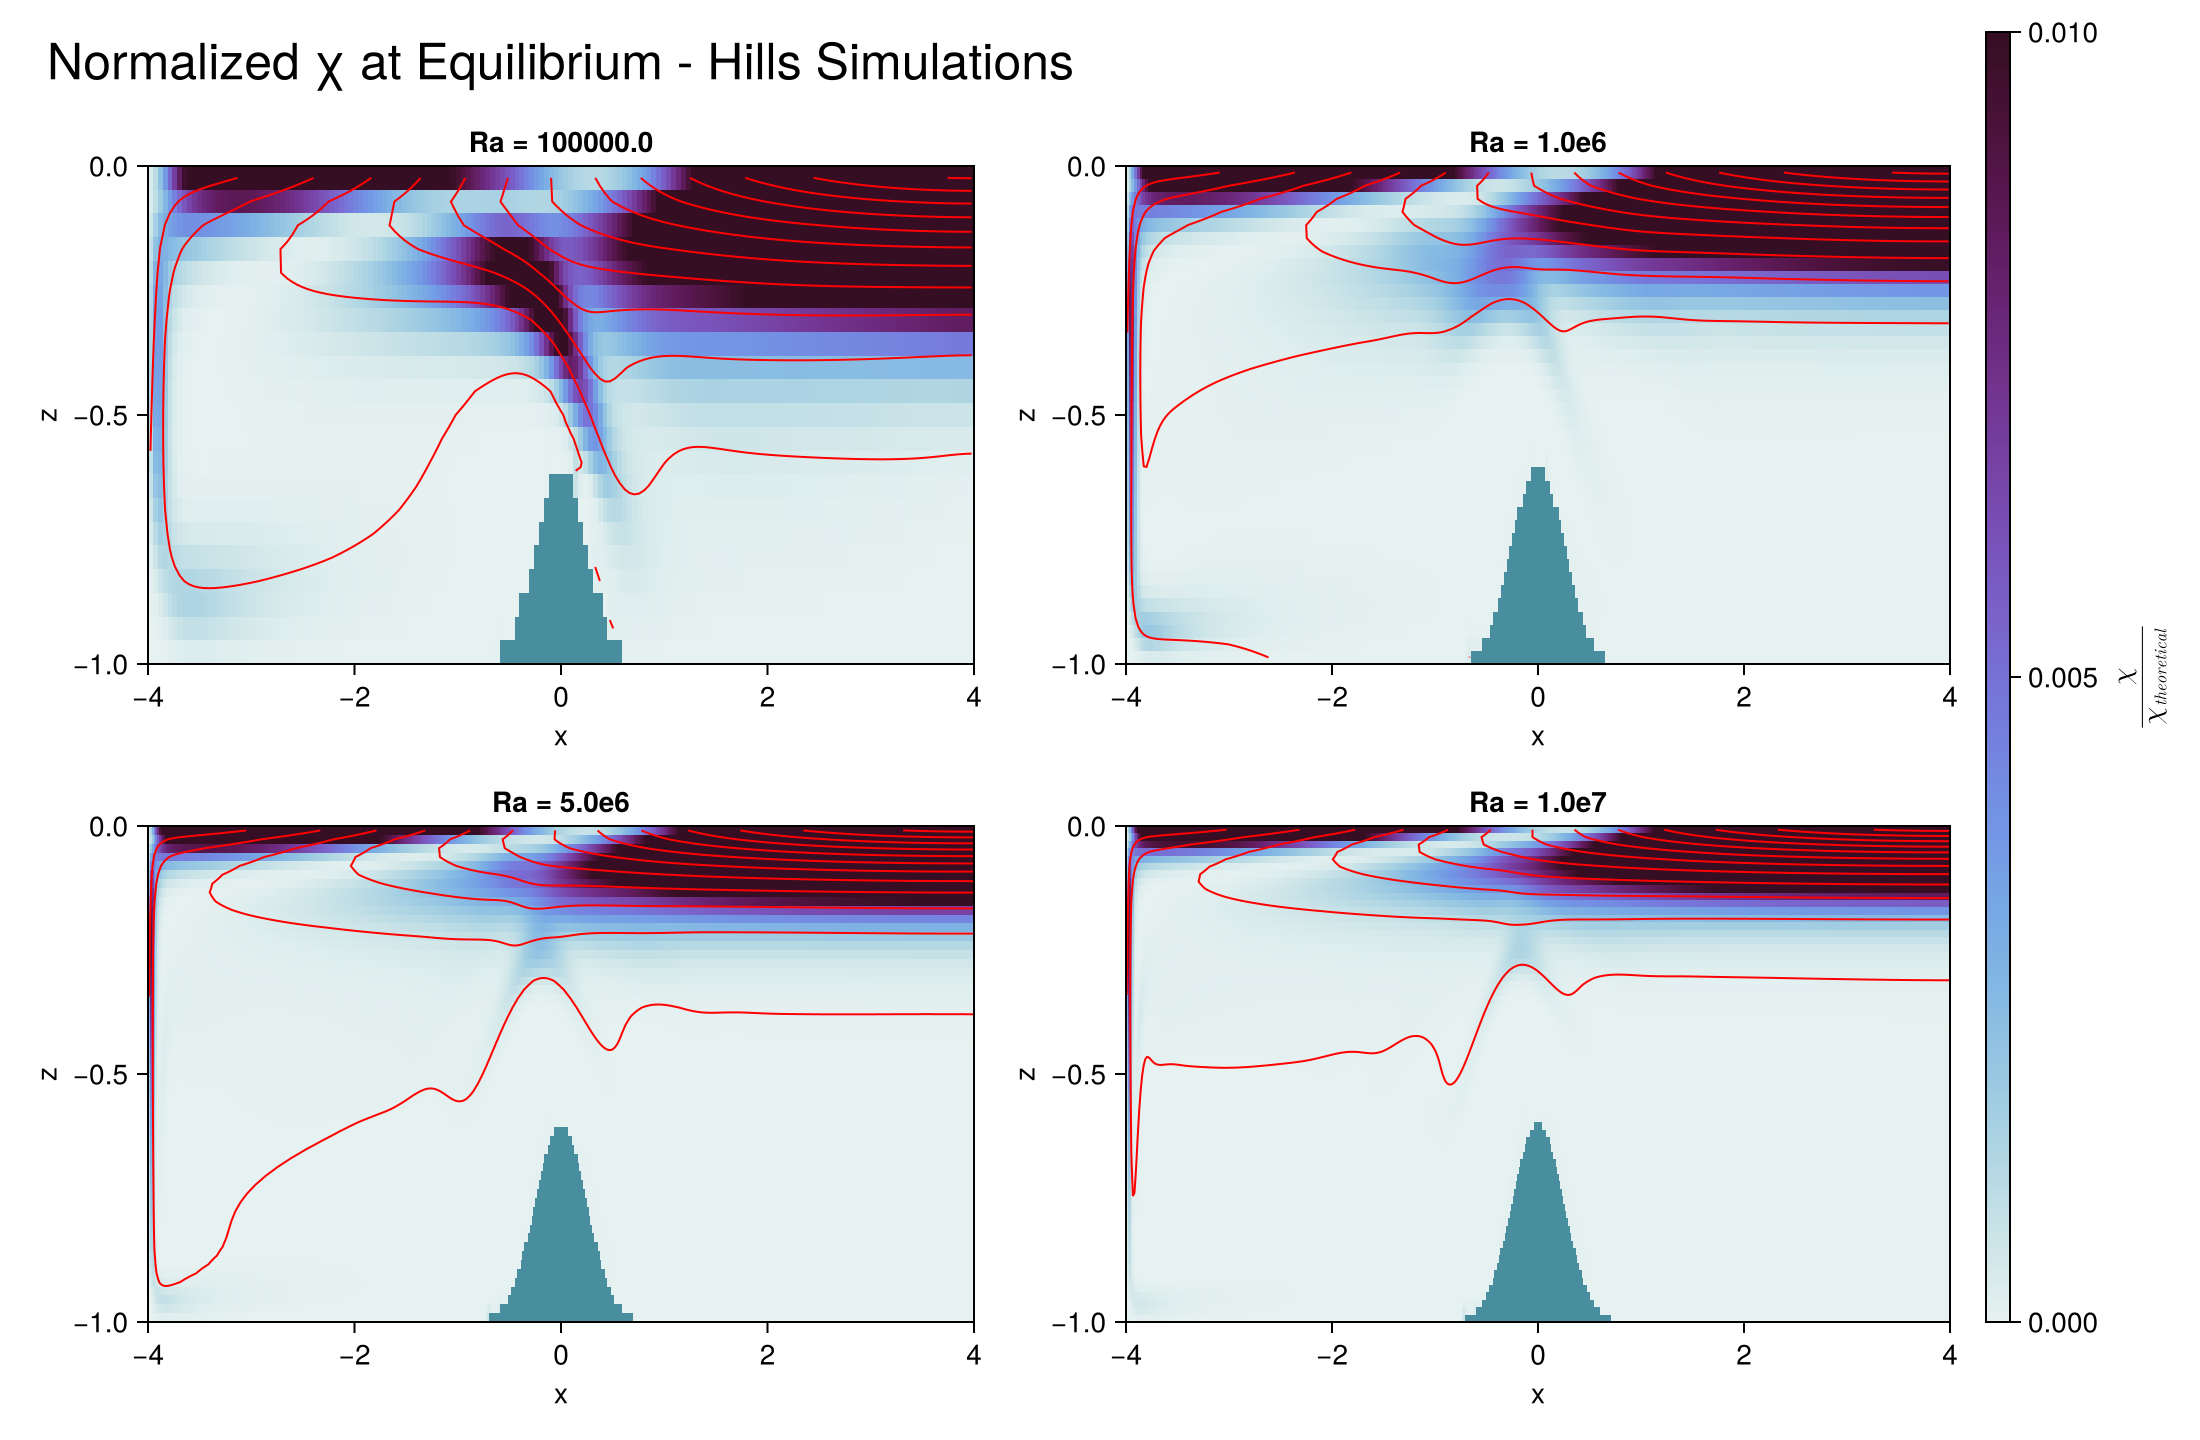

In [8]:
# create χ heatmaps for hills simulations
χ_hm_hills = diss_norm_eq_subplots(list_hill_datasets, list_hill_ds_buoy, "χ", (0, 0.01), cols=2, 
        main_title="Normalized χ at Equilibrium - Hills Simulations")
χ_hm_hills


Now we want to repeat the scatter plots for $\chi_{mean}$, the time averaged volume integrated buoyancy dissipation over the equilibrium time (last 10% of the simulation time).

we also want to add the theoretical $\chi$ prediction curve to this plot, but need to nondimensionalize since we are plotting both versus Rayleigh number which is a nondimensional parameter.

Recall : 
$$\chi_{theory} = 4.57 \frac{\kappa^{1/3} (2 b_{\bigstar})^{7/3}}{{Pr}^{1/3}H} $$

the buoyancy dissipation parameter, $\chi$ comes from multiplying the buoyancy conservation equation by buoyancy and integrating it over the volume of the domain and then taking the time average. Upon manipulation of the equations, we're left with $\chi = \kappa \langle |\nabla b|^2 \rangle $. This scales as $\frac{\kappa b_{\bigstar}^2}{H^2}$. We can break this further to $\frac{m^2/s m^2/s^4}{m^2} = \frac{m^2}{s^5} = \frac{\kappa^5}{H^8}$

Therefore, in order to nondimensionalize $\chi_{theory}$ and time averaged $\chi$ from simulation we need to divide by the scaling parameter: $\frac{\kappa^5}{H^8}$

 $\frac{\chi_{theory}}{\kappa^5 H^{-8}} = 4.57 (2)^{7/3} Ra^{7/3} $


I'll nondimensionalize $\chi_{mean}$ from the simulation within the code. 

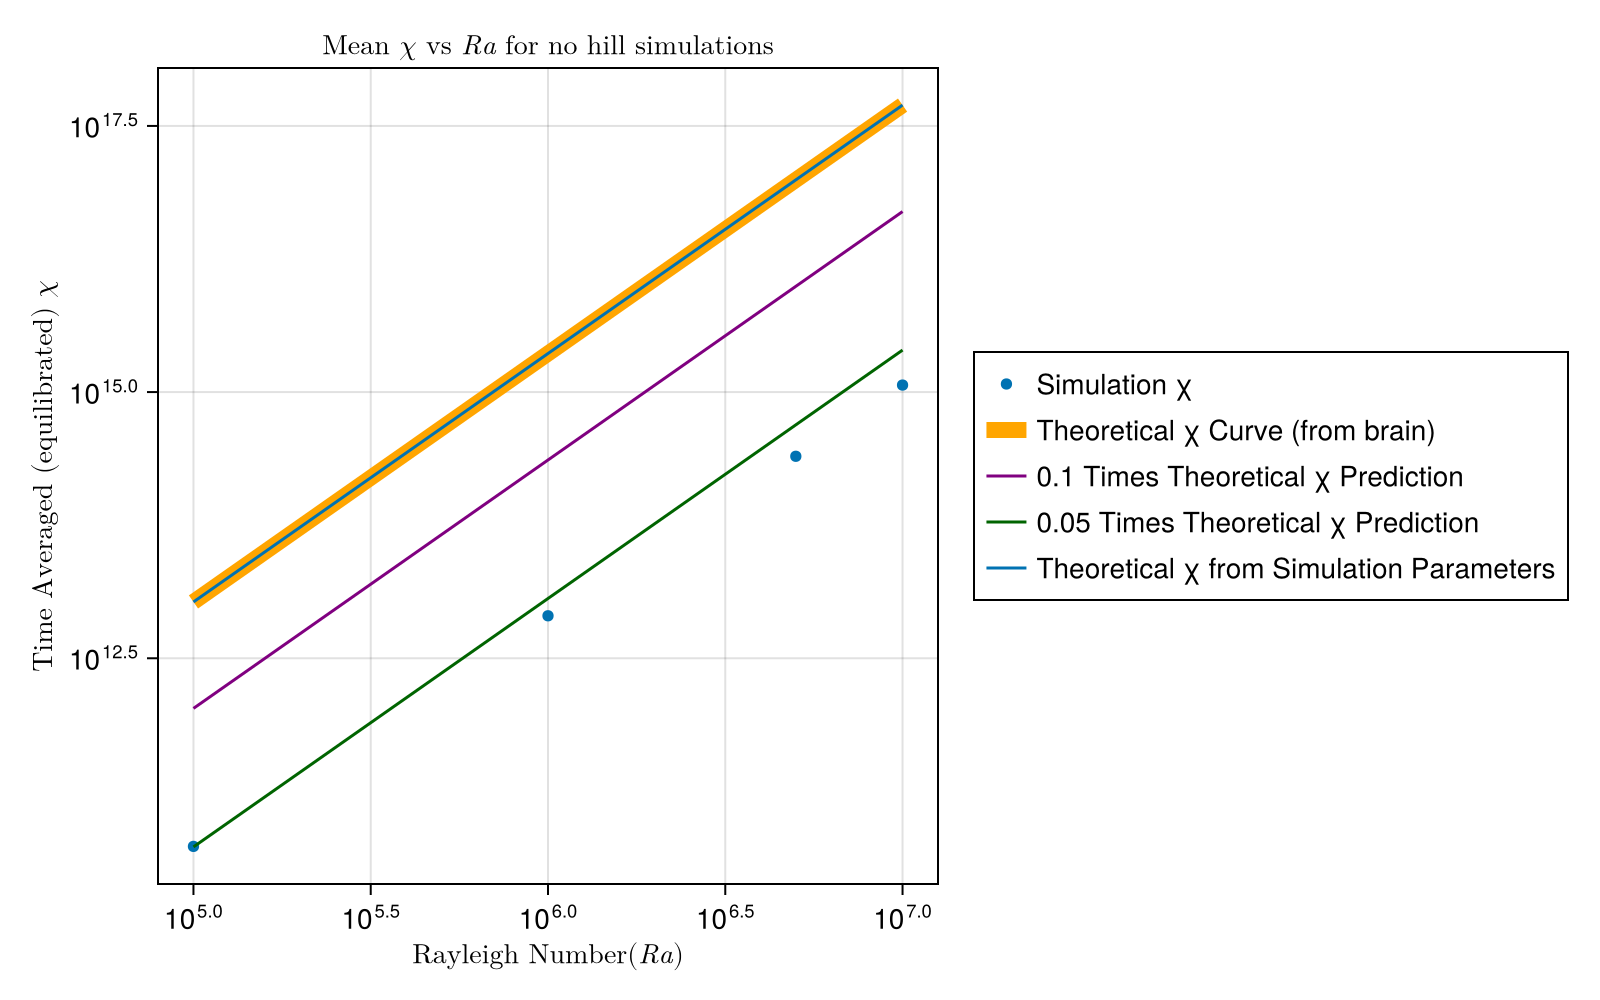

In [27]:
f_χ_scatter = Figure(size = (800, 500))
ax_χ_scat = Axis(f_χ_scatter[1, 1], 
    xscale = log10, 
    yscale = log10,
    xlabel=L"\text{Rayleigh Number} (Ra)", 
    ylabel=L"\text{Time Averaged (equilibrated) } χ", 
    title=L"\text{Mean } χ \text{ vs } Ra \text{ for no hill simulations}")

Ra_vals = Float64[]
χ_means = Float64[]
χ_theories_from_sim = Float64[]
χ_theories_from_brain = Float64[]

for ds in list_of_datasets
    κ = ds.attrib["κ"]
    H = ds.attrib["H"]
    Ra = ds.attrib["Ra"]
    b★ = ds.attrib["b★"]
    χ_mean = dissipation_analysis(ds, "χ")[3] ./ (κ^5 / H^8) # nondimensionalize χ_mean
    χ_sim_theory = dissipation_analysis(ds, "χ")[1] ./ ((κ^5) / H^8) # nondimensionalize χ_sim_theory

    push!(Ra_vals, Ra)
    push!(χ_means, χ_mean)
    push!(χ_theories_from_brain, 4.57 * 2^(7/3) * Ra^(7/3)) #nondimensionalized theoretical χ calculated from "brain" lol
    push!(χ_theories_from_sim, χ_sim_theory) #nondimensionalized theoretical χ calculated from simulation parameters
end

#plot the scatter points
scatter!(ax_χ_scat, Ra_vals, χ_means, label="Simulation χ", markersize=8)
#theoretical prediction curve
lines!(ax_χ_scat, Ra_vals, χ_theories_from_brain, label="Theoretical χ Curve (from brain)", linewidth=8, color=:orange)
lines!(ax_χ_scat, Ra_vals, χ_theories_from_brain .* 0.1, label="0.1 Times Theoretical χ Prediction", color=:purple)
lines!(ax_χ_scat, Ra_vals, χ_theories_from_brain .* 0.005, label="0.05 Times Theoretical χ Prediction", color=:darkgreen)
lines!(ax_χ_scat, Ra_vals, χ_theories_from_sim, label = "Theoretical χ from Simulation Parameters")
Legend(f_χ_scatter[1, 2], ax_χ_scat)
f_χ_scatter


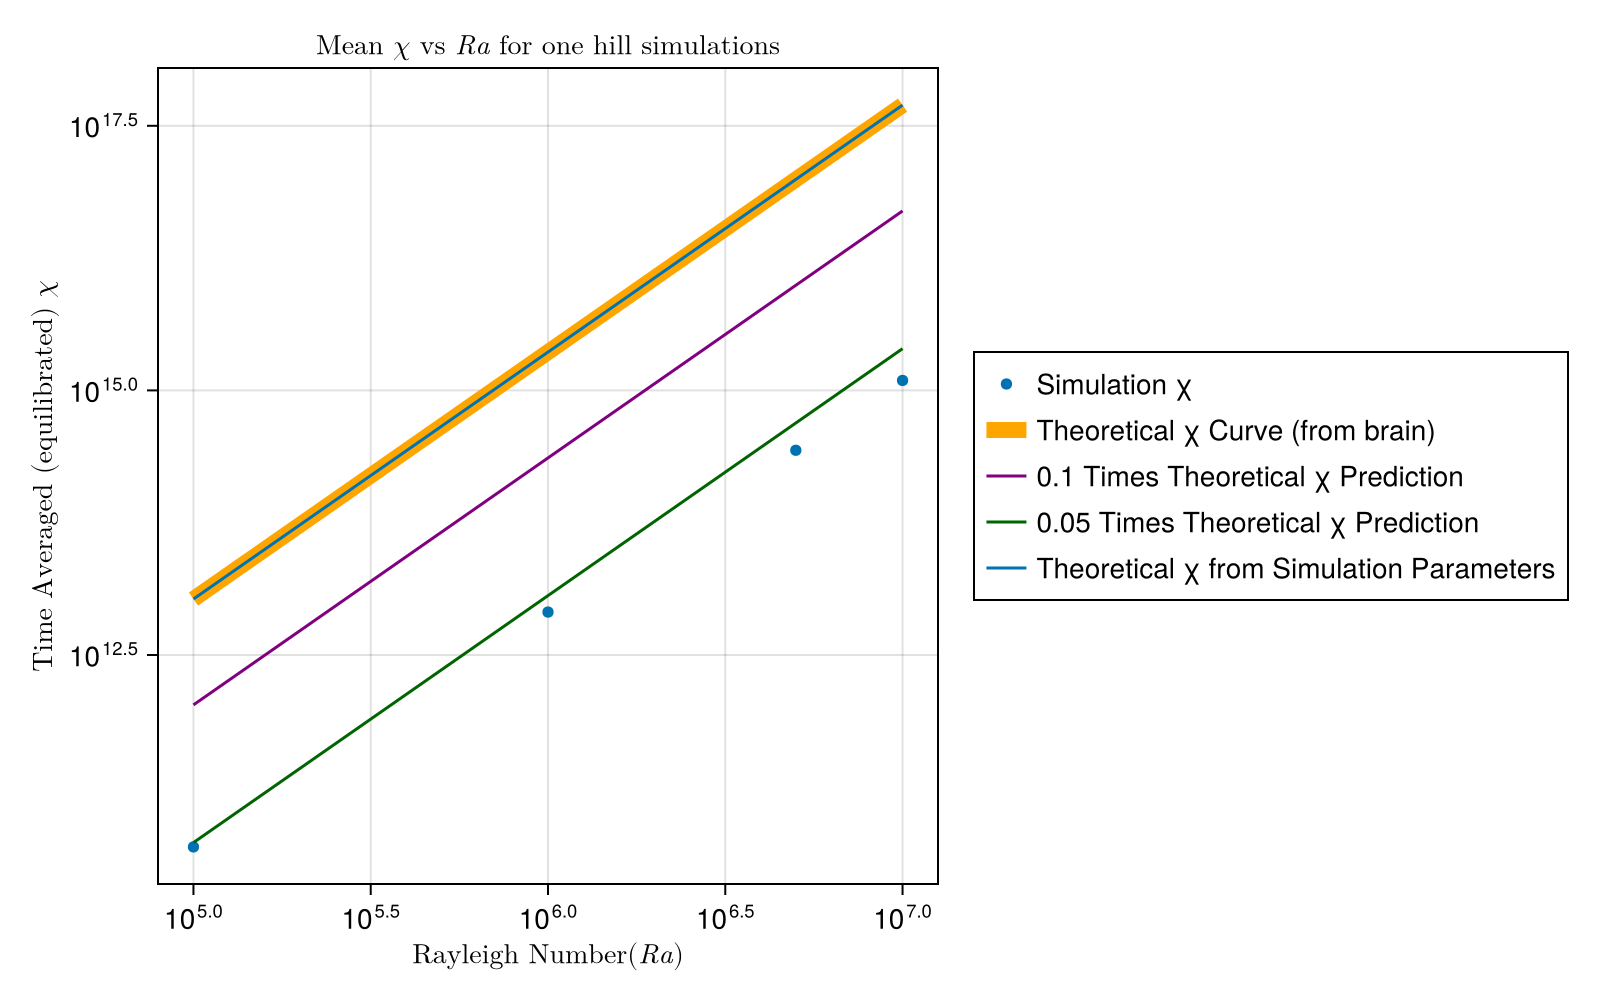

In [28]:
f_χ_scatter_hill = Figure(size = (800, 500))
ax_χ_scat_hill = Axis(f_χ_scatter_hill[1, 1], 
    xscale = log10, 
    yscale = log10,
    xlabel=L"\text{Rayleigh Number} (Ra)", 
    ylabel=L"\text{Time Averaged (equilibrated) } χ", 
    title=L"\text{Mean } χ \text{ vs } Ra \text{ for one hill simulations}")

Ra_vals_hill = Float64[]
χ_means_hill = Float64[]
χ_theories_from_sim_hill = Float64[]
χ_theories_from_brain_hill = Float64[]

for ds in list_hill_datasets
    κ = ds.attrib["κ"]
    H = ds.attrib["H"]
    Ra = ds.attrib["Ra"]
    b★ = ds.attrib["b★"]
    χ_mean = dissipation_analysis(ds, "χ")[3] ./ ((κ^5) / H^8) # nondimensionalize χ_mean
    χ_sim_theory = dissipation_analysis(ds, "χ")[1] ./ ((κ^5) / H^8) # nondimensionalize χ_sim_theory

    push!(Ra_vals_hill, Ra)
    push!(χ_means_hill, χ_mean)
    push!(χ_theories_from_brain_hill, 4.57 * 2^(7/3) * Ra^(7/3)) #nondimensionalized theoretical χ calculated from "brain" lol
    push!(χ_theories_from_sim_hill, χ_sim_theory) #nondimensionalized theoretical χ calculated from simulation parameters
end

#plot the scatter points
scatter!(ax_χ_scat_hill, Ra_vals_hill, χ_means_hill, label="Simulation χ", markersize=8)
#theoretical prediction curve
lines!(ax_χ_scat_hill, Ra_vals_hill, χ_theories_from_brain_hill, label="Theoretical χ Curve (from brain)", linewidth=8, color=:orange)
lines!(ax_χ_scat_hill, Ra_vals_hill, χ_theories_from_brain_hill .* 0.1, label="0.1 Times Theoretical χ Prediction", color=:purple)
lines!(ax_χ_scat_hill, Ra_vals_hill, χ_theories_from_brain_hill .* 0.005, label="0.05 Times Theoretical χ Prediction", color=:darkgreen)
lines!(ax_χ_scat_hill, Ra_vals_hill, χ_theories_from_sim_hill, label = "Theoretical χ from Simulation Parameters")
Legend(f_χ_scatter_hill[1, 2], ax_χ_scat_hill)
f_χ_scatter_hill

In [10]:
#import velocity data 

ds0_v = NCDataset(string("/Users/hfdrake/code/HorizontalConvection/output/turbulent_flat_0_Ra100000.0_coldstart/velocities.nc"));
ds1_v = NCDataset(string("/Users/hfdrake/code/output/turbulent_h0_Ra1.0e6_coldstart_velocities.nc"));
ds2_v = NCDataset(string("/Users/hfdrake/code/output/turbulent_flat_0.6_Ra5.0e6_coldstart_velocities.nc"));
ds3_v = NCDataset(string("/Users/hfdrake/code/HorizontalConvection/output/turbulent_flat_0_Ra1.0e7_coldstart/velocities.nc"));

list_ds_vel = [ds0_v, ds1_v, ds2_v, ds3_v];


ds_h0_v = NCDataset(string("/Users/hfdrake/code/HorizontalConvection/output/turbulent_onehill_0.6_Ra100000.0_coldstart_velocities.nc"));
ds_h1_v = NCDataset(string("/Users/hfdrake/code/HorizontalConvection/output/turbulent_onehill_0.6_Ra1.0e6_coldstart_velocities.nc"));
ds_h2_v = NCDataset(string("/Users/hfdrake/code/HorizontalConvection/output/turbulent_onehill_0.6_Ra5.0e6_coldstart_velocities.nc"));
ds_h3_v = NCDataset(string("/Users/hfdrake/code/HorizontalConvection/output/turbulent_onehill_0.6_Ra1.0e7_coldstart_velocities.nc"));

list_hill_ds_vel = [ds_h0_v, ds_h1_v, ds_h2_v, ds_h3_v];

In [40]:
x = ds0_v["xC"][4+1:end-4];
z = ds0_v["zC"][4+1:end-4];
time = ds0_v["time"];
eq_start = round(Int, 0.9 * size(time, 1)); # 90% of the way through the simulation
b_eq = ds0["b"][4+1:end-4, 1, 4+1:end-4, eq_start:end];
wet = b_eq.!= 0 # wet points are those where b_eq is not zero
b_eq[.!wet] .= NaN; # set dry points to NaN
b_avg = nanmean(b_eq, dims=4)
b_avg_2d = dropdims(b_avg, dims=(4, 2)) # remove the time and y dimension

ψ = get_ψ(ds0_v)[:, 1, :, eq_start:end] # select y=1 slice
ψ_avg = nanmean(ψ, dims=4)
ψ_avg_2d = dropdims(ψ_avg, dims=(4, 2)) # remove the time and y dimension

f_ψ = Figure(size=(800,600))
ax_ψ = Axis(f_ψ, aspect = 8, xlabel="x", ylabel="z")
p1 = heatmap!(ax_ψ, x, z, ψ_avg_2d', colormap=:balance) # transpose for correct orientation
contour!(ax_ψ, x, z, b_avg_2d', levels=15, labels=true, colormap=:thermal, color=:black)
cbar = Colorbar(f_ψ, p1, label="Streamfunction (ψ)")
f_ψ





String: "Dimension `4` not found."

In [9]:
ds_h1_b = NCDataset(string("/Users/hfdrake/code/HorizontalConvection/output/turbulent_onehill_0.6_Ra1.0e6_coldstart_buoyancy.nc"));
ds_h1_o = NCDataset(string("/Users/hfdrake/code/HorizontalConvection/output/turbulent_onehill_0.6_Ra1.0e6_coldstart_oceanostics.nc"));


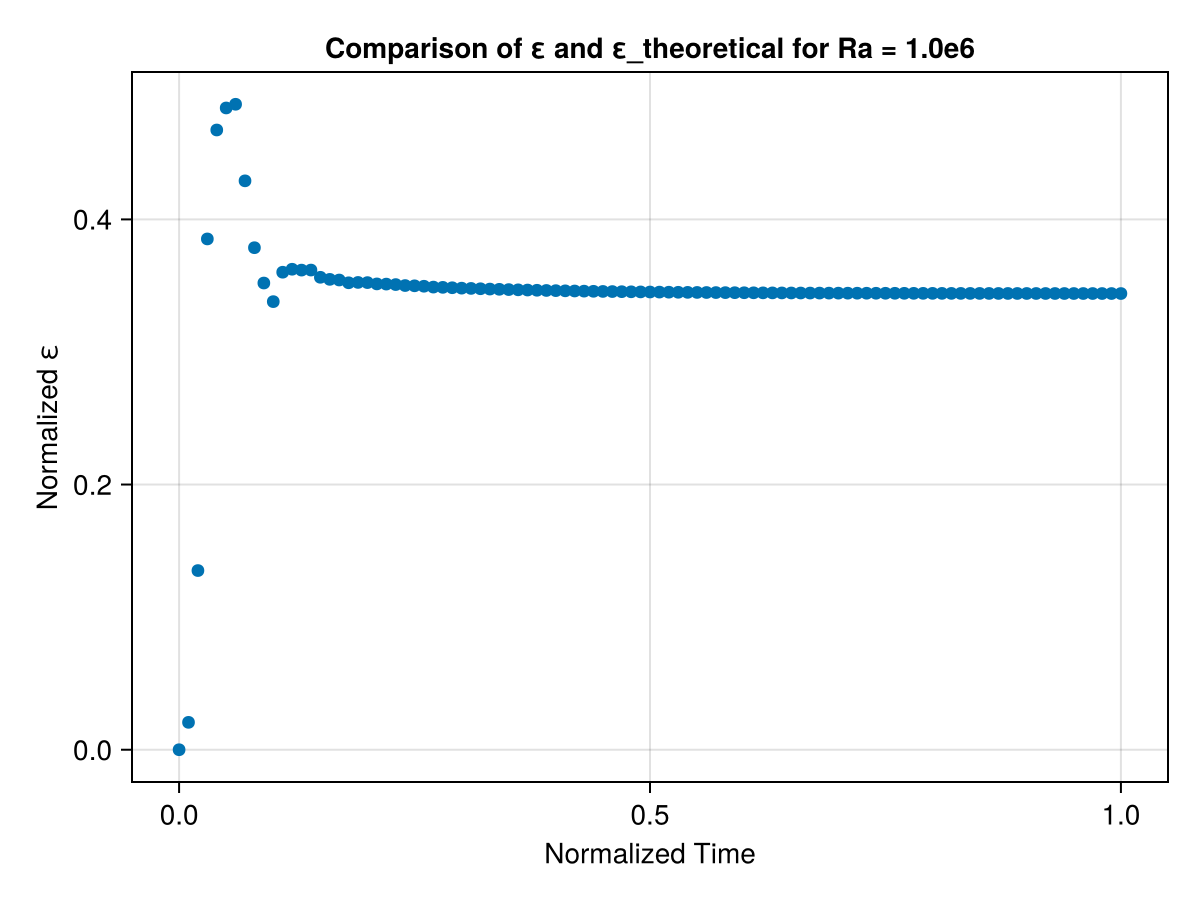

In [18]:
ε_theory_h1, ε_avg_h1, ε_mean_h1 = ε_analysis(ds_h1_o);
f_h1 = plot_ε_normalized(ds_h1_o)

f_h1

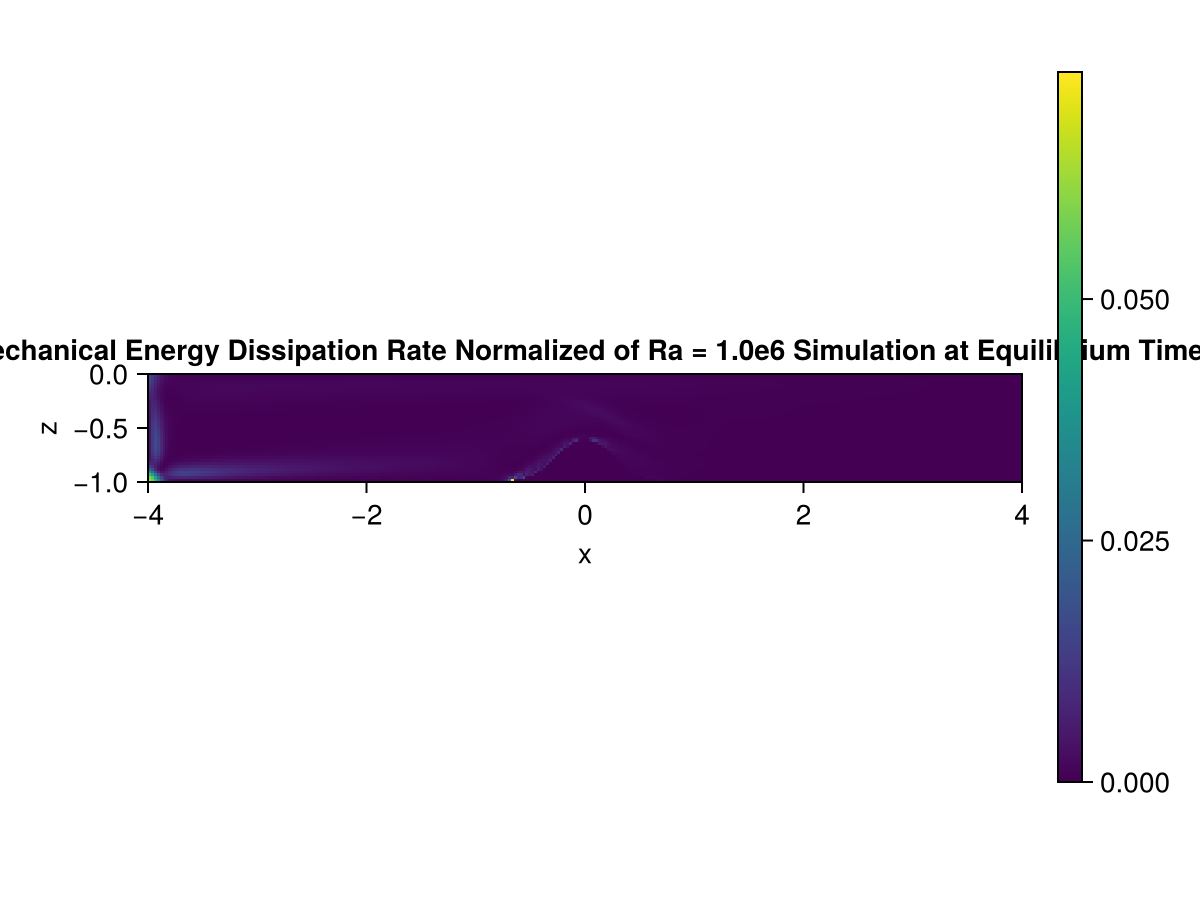

In [65]:
fig5 = plot_ε_equilibrium(ds_h1_o)

In [10]:
#Ra 5e6 one hill 

ds_h2_b = NCDataset(string("/Users/hfdrake/code/HorizontalConvection/output/turbulent_onehill_0.6_Ra5.0e6_coldstart_buoyancy.nc"));
ds_h2_o = NCDataset(string("/Users/hfdrake/code/HorizontalConvection/output/turbulent_onehill_0.6_Ra5.0e6_coldstart_oceanostics.nc"));


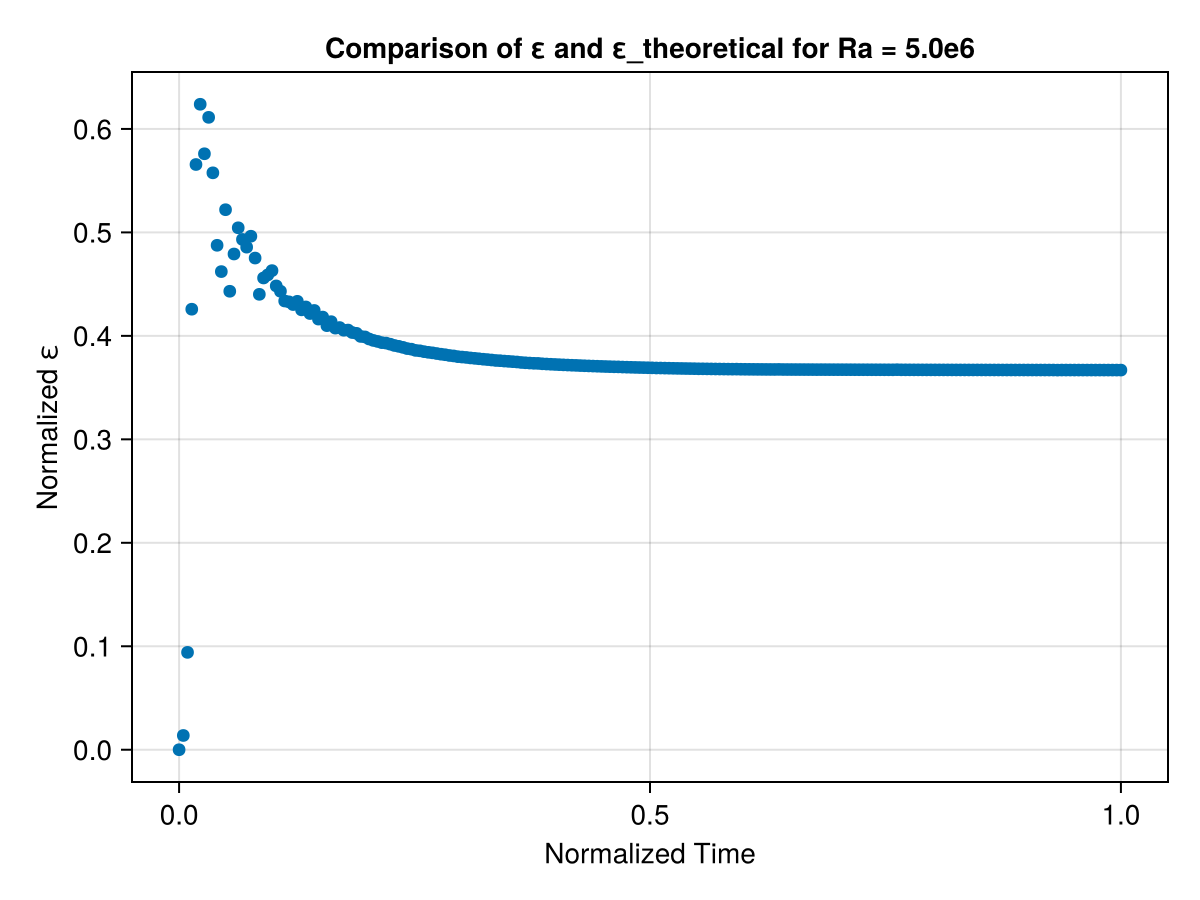

In [108]:
ε_theory_h2, ε_avg_h2, ε_mean_h2 = ε_analysis(ds_h2_o);
f_h2 = plot_ε_normalized(ds_h2_o);

Rayleigh number 1e7 with one hill

<video width="600" height="400" controls>
    <source src="/Users/hfdrake/code/HorizontalConvection/animations/onehill1e7.mp4" type "video/mp4">
</video>

In [11]:
#Ra 1e7 one hill

ds_h3_b = NCDataset(string("/Users/hfdrake/code/HorizontalConvection/output/turbulent_onehill_0.6_Ra1.0e7_coldstart_buoyancy.nc"));
ds_h3_o = NCDataset(string("/Users/hfdrake/code/HorizontalConvection/output/turbulent_onehill_0.6_Ra1.0e7_coldstart_oceanostics.nc"));

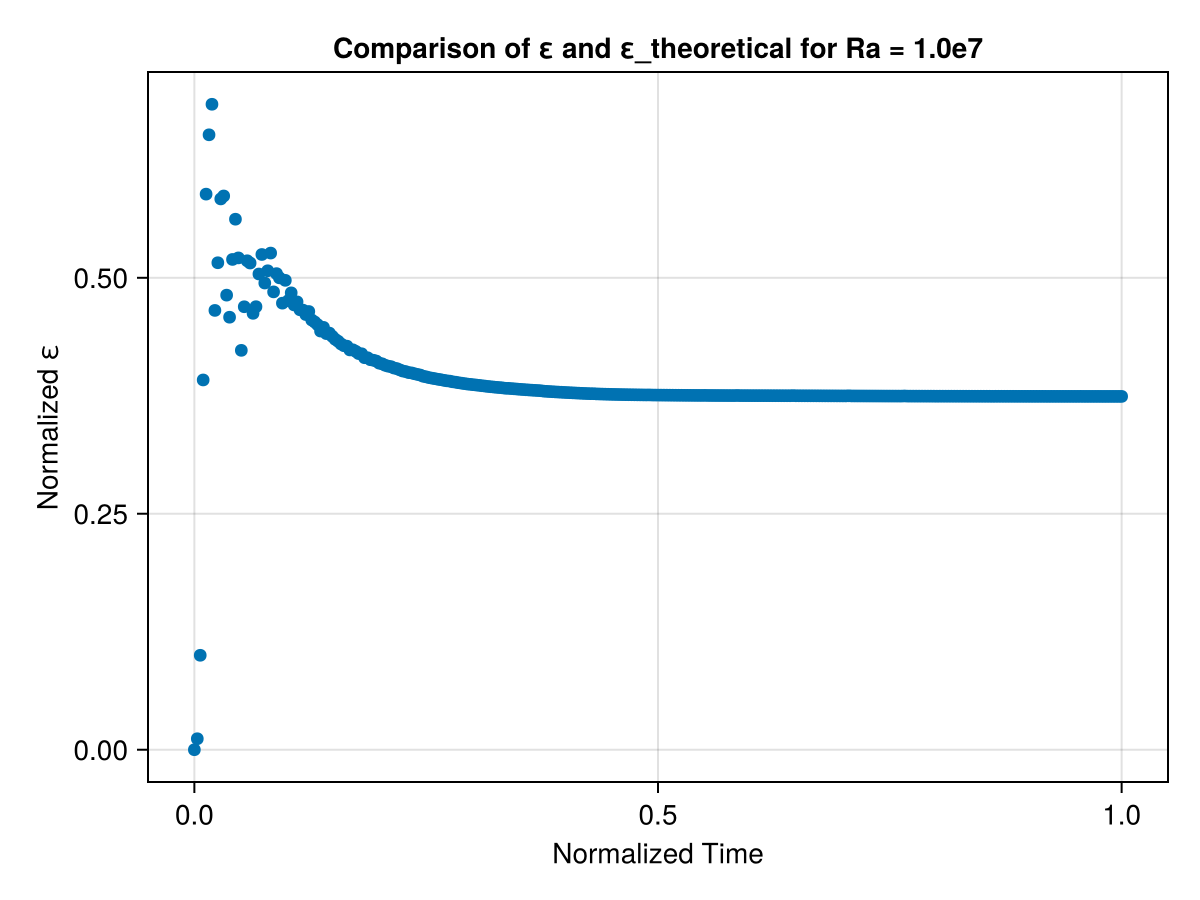

In [110]:
ε_theory_h3, ε_avg_h3, ε_mean_h3 = ε_analysis(ds_h3_o);
f_h3 = plot_ε_normalized(ds_h3_o)

In [107]:
b = ds_h3_b["b"][4+1:end-4, :, 4+1:end-4, :];
time = ds_h3_b["time"][:];

okay, time to make a joint plot of normalized epsilon vs time for all RA

lets start with no hills

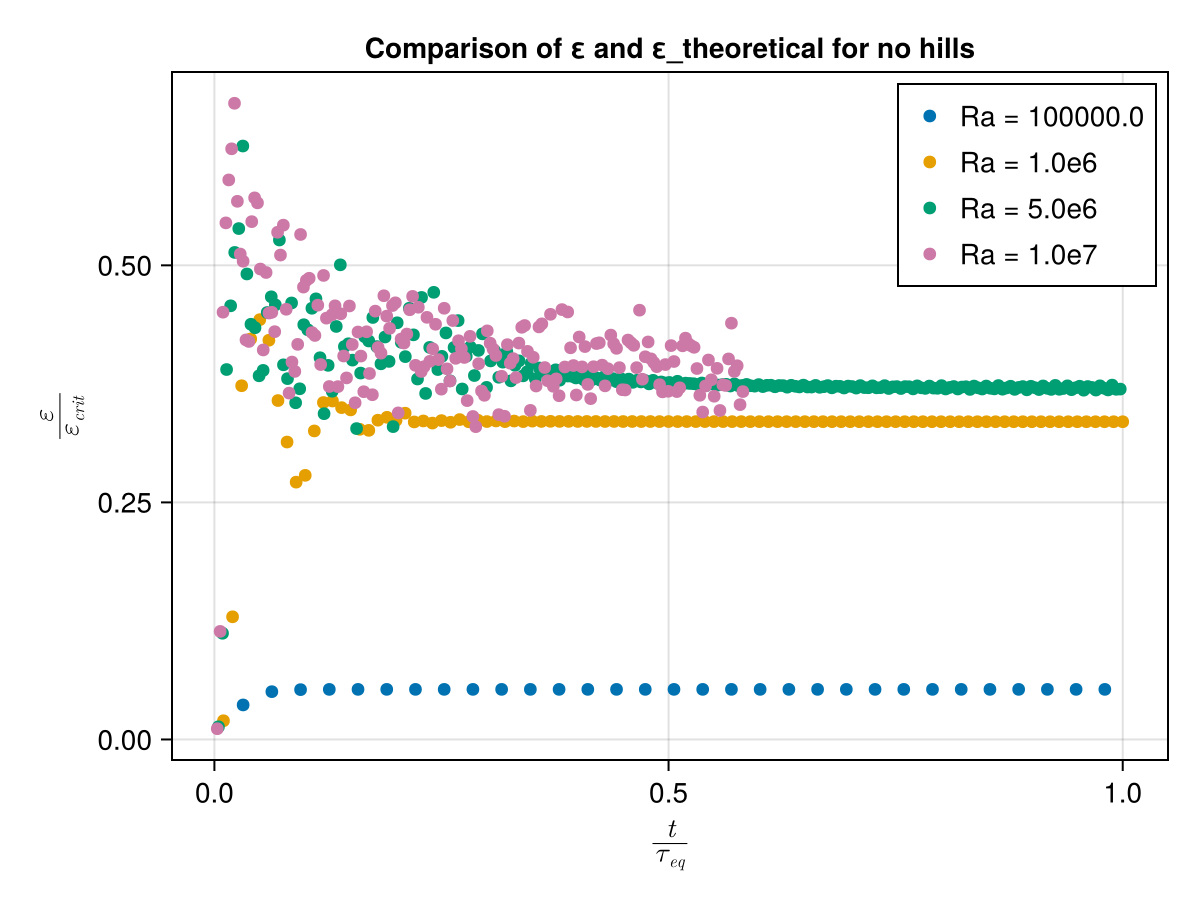

In [85]:
f = Figure()
ax = Axis(f[1, 1], xlabel=L"\frac{t}{\tau_{eq}}", ylabel=L"\frac{ε}{ε_{theoretical}}", title="Comparison of ε and ε_theoretical for no hills")
for ds in list_of_datasets
    plot_normalized(ax, ds, "ε")
end

axislegend(ax)
f

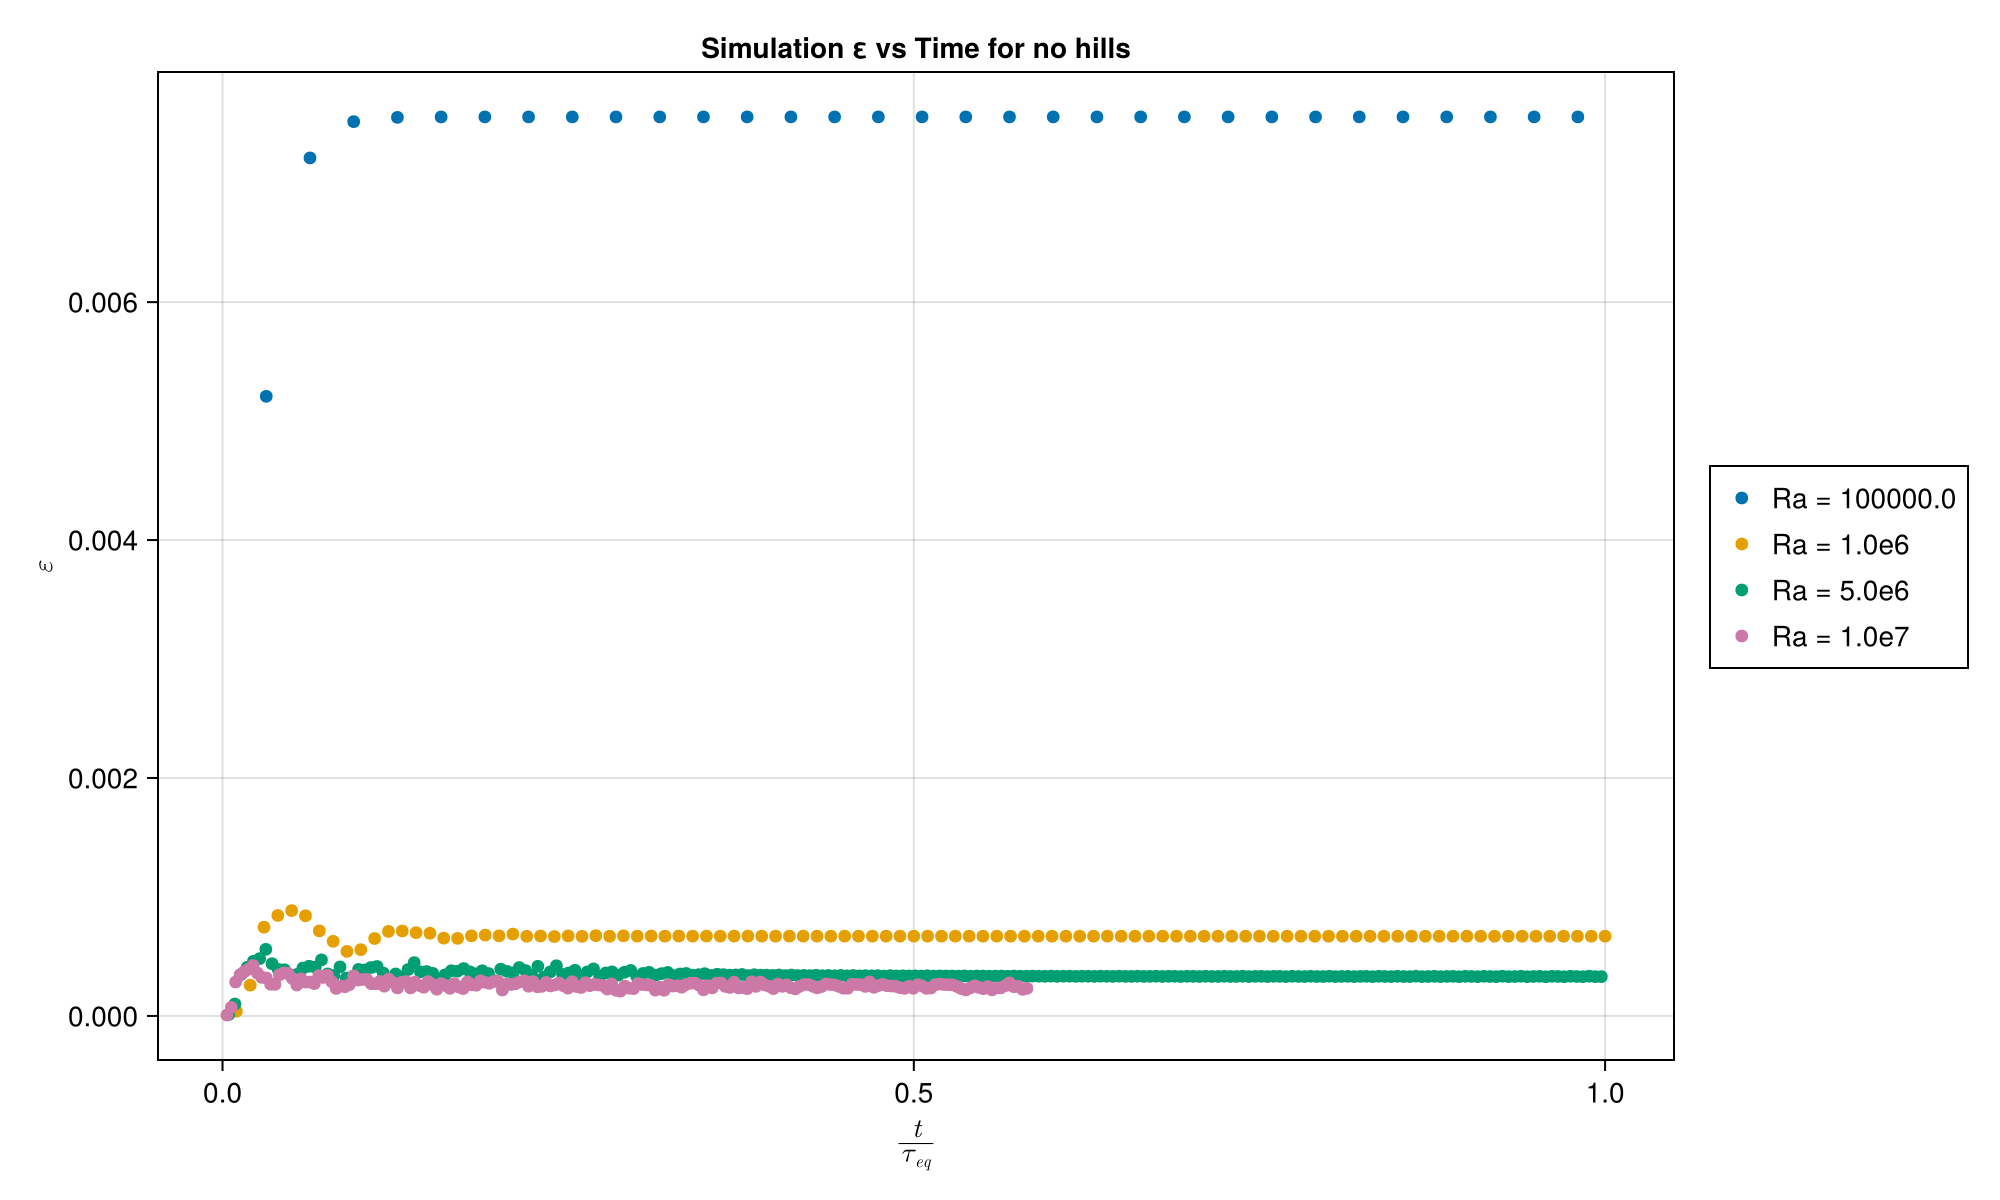

In [86]:
f1 = Figure(size=(1000, 600))
ax1 = Axis(f1[1, 1], xlabel=L"\frac{t}{\tau_{eq}}", ylabel=L"\varepsilon", title="Volume Averaged ε vs Time for no hills")
for ds in list_of_datasets
    plot_avg(ax1, ds, "ε")
end
Legend(f1[1, 2], ax1)  # Place legend in separate column
f1

Next, we want to make a scatter plot for the mean $\varepsilon$ averaged over the equilibrium period versus the Rayleigh number.

We also want to add theoretical $\varepsilon$ prediction curve to this plot. 

Recall : $\varepsilon_{crit} = 2 \kappa b_{\bigstar} H^{-1} $

We want $\varepsilon_{crit} $ as a function of the Rayleigh number, $Ra$. and Rayleigh number: $Ra = \frac{b_{\bigstar} H^3}{\nu \kappa}$

therefore, $\kappa = \frac{b_{\bigstar}H^3}{\nu Ra} $ and $\nu = \sqrt{\frac{Pr b_{\bigstar} H^3 } {Ra}}$ and $Pr = \frac{\nu}{\kappa}$ where Pr = 1

$b_{\bigstar} = H = 1 $ and $Pr = 1 $ , therefore $\nu = \kappa = \frac{1}{\sqrt{Ra}} $

and $\varepsilon_{crit} = \frac{2}{\sqrt{Ra}} $

okay, so the pink theoretical $\varepsilon$ curve comes from the algebraic manipulation of the definitions, plugging in the simulation parameters that remain constant ($H, b_{\bigstar}, \text{and } Pr$), and solving as a function of rayleigh number. This gave us $\varepsilon = \frac{2}{\sqrt{Ra}}$

the blue theoretical $\varepsilon$ curve comes from the plugging in the global attributes of the simulation directly into the theoretical definition of $\varepsilon = 2 \kappa b_{\bigstar} H^{-1} $

It's clear from the figure above that something went wrong with the $Ra = 1e5$ and $Ra = 5e6$ simulations. 

In [58]:
println(Ra_vals)
println(ε_means)
println(ε_theories)

[100000.0, 1.0e6, 5.0e6, 1.0e7]
[0.007556579026952185, 0.0006701613638236988, 0.006982914448636357, 0.00024311562110557473]
[0.14310835055998655, 0.002, 0.020238577025077628, 0.0006324555320336759]


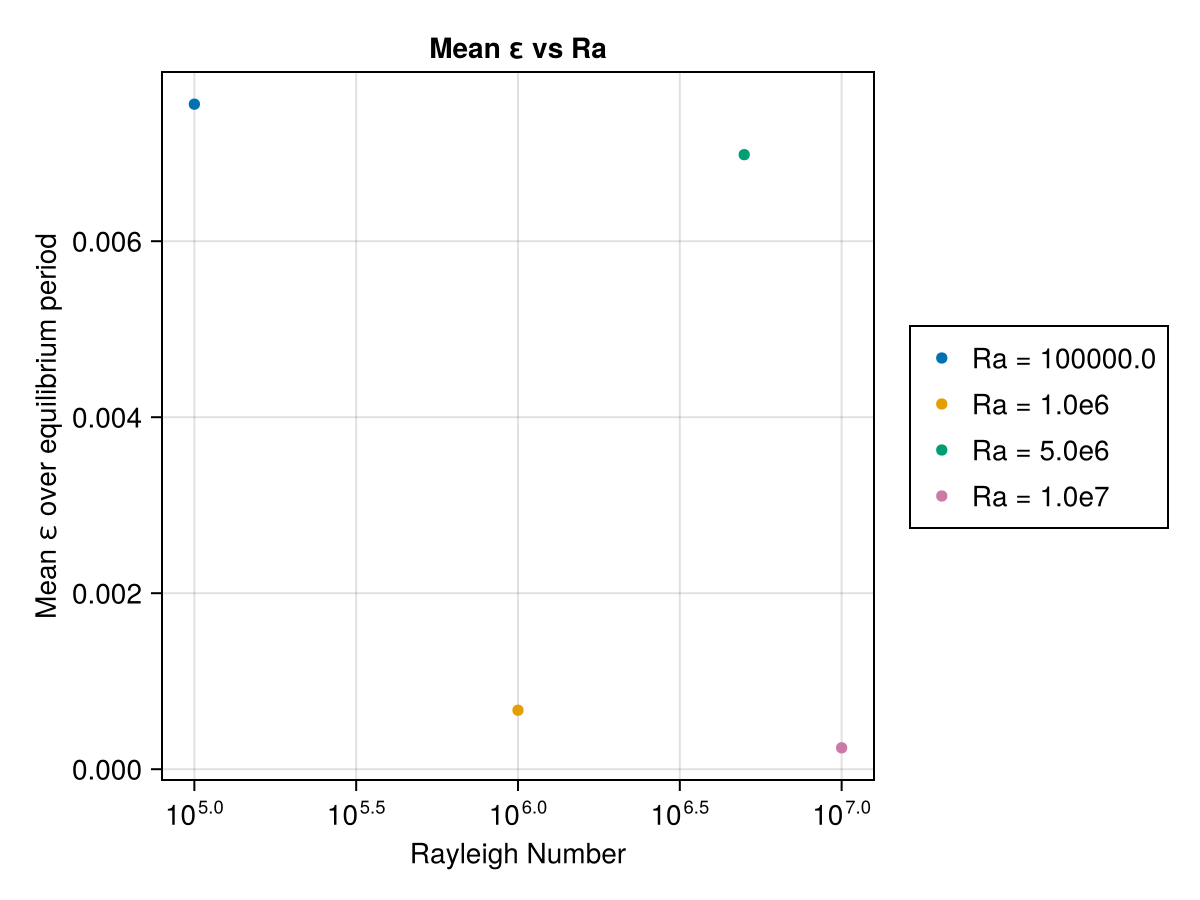

In [28]:
f_ε_scatter = Figure()
ax_ε_scatter = Axis(f_ε_scatter[1, 1], xscale = log10, xlabel="Rayleigh Number", ylabel="Mean ε over equilibrium period", title="Mean ε vs Ra")

for ds in list_of_datasets
    ε_mean = ε_analysis(ds)[3]
    Ra = ds.attrib["Ra"]
    b★ = ds.attrib["b★"]
    ν = ds.attrib["ν"]
    H = ds.attrib["H"]
    
    scatter!(ax_ε_scatter, Ra, ε_mean, label=string("Ra = ", Ra), markersize=8)
end
Legend(f_ε_scatter[1,2], ax_ε_scatter)  # Add the legend
f_ε_scatter
  



<video width="600" height="400" controls>
    <source src="/Users/hfdrake/code/HorizontalConvection/animations/onehill5e6.mp4" type "video/mp4">
</video>

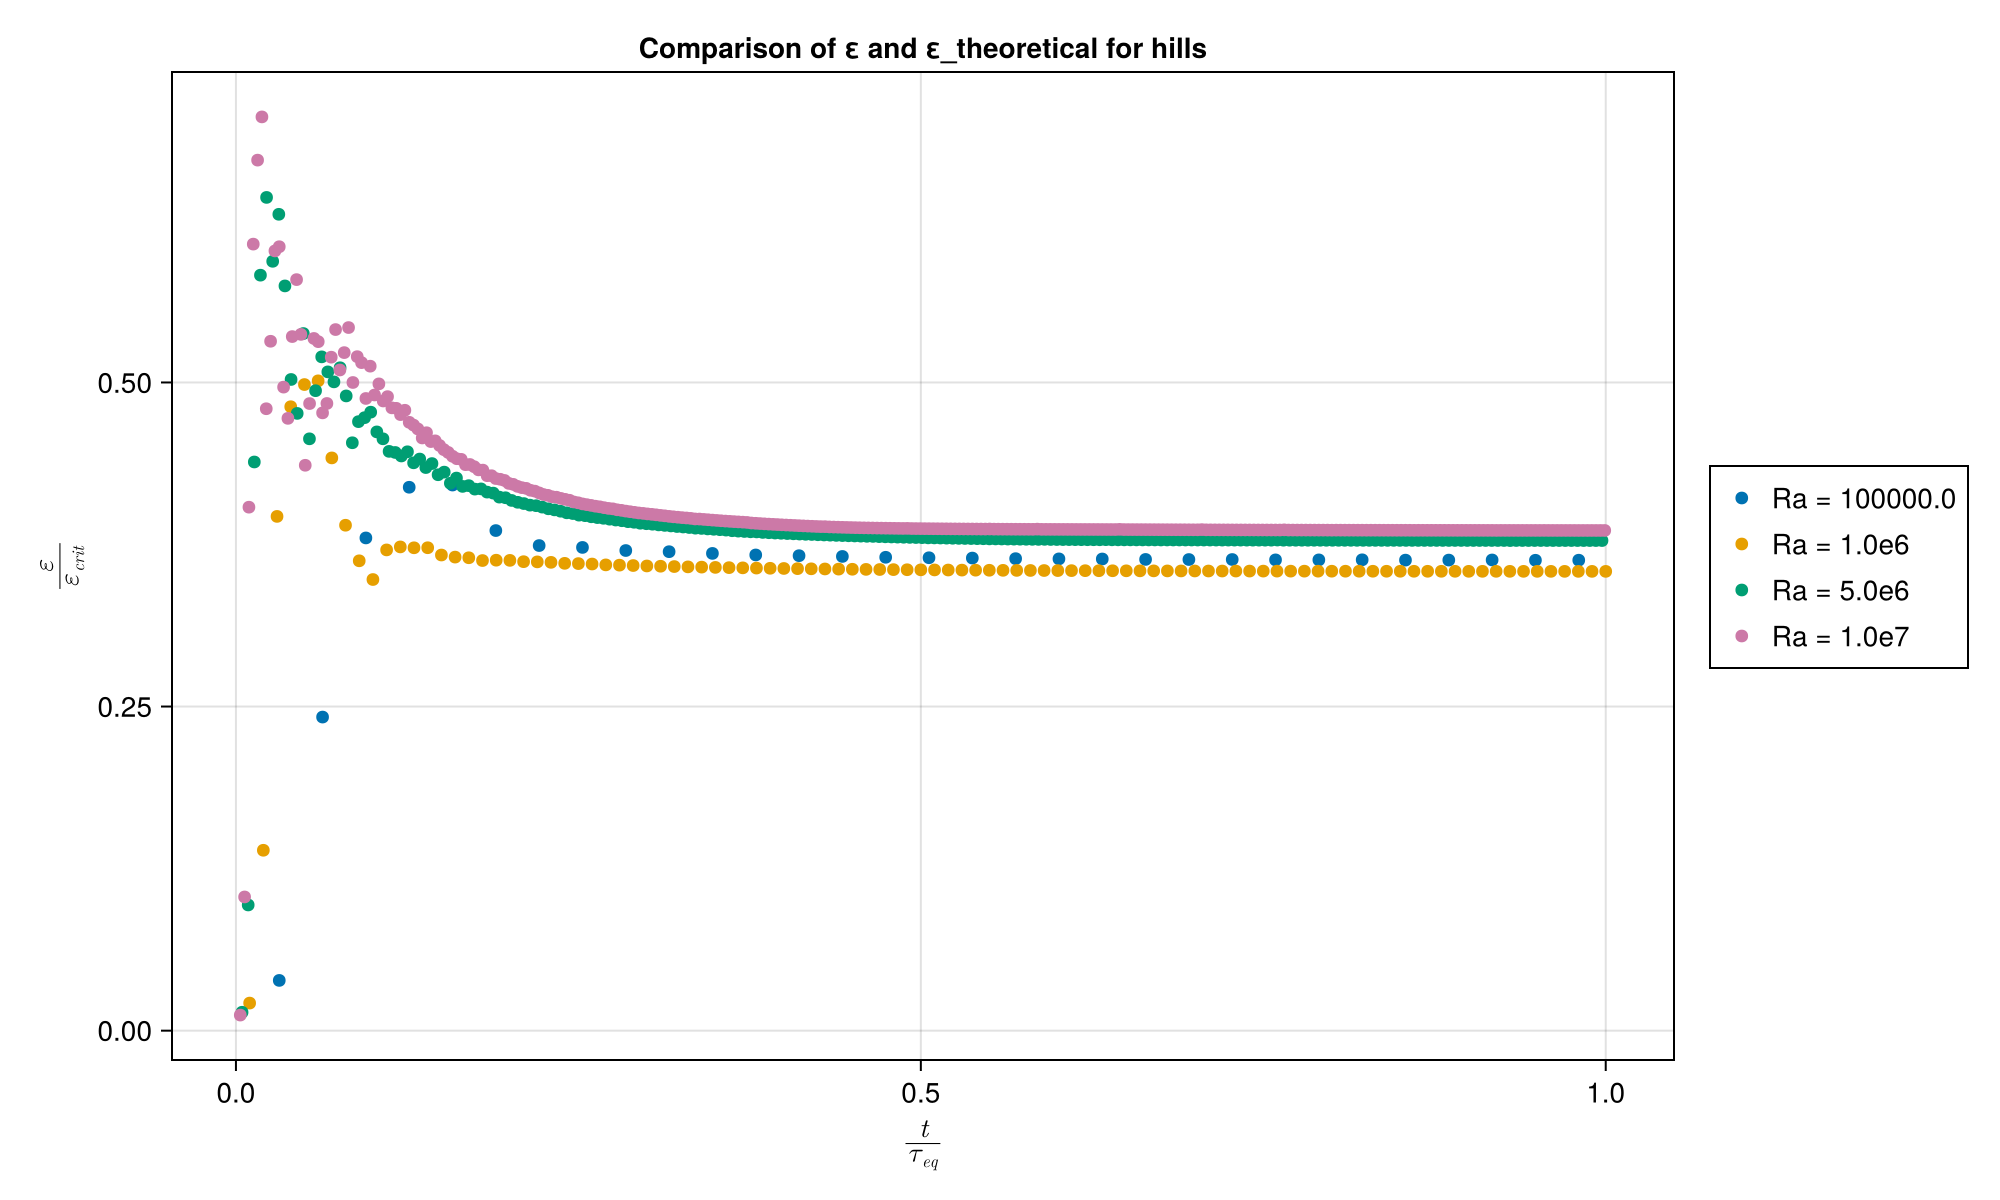

In [23]:
f_hills = Figure(size=(1000, 600))
ax_hills = Axis(f_hills[1, 1], xlabel=L"\frac{t}{\tau_{eq}}", ylabel=L"\frac{ε}{ε_{theoretical}}", title="Comparison of ε and ε_theoretical for hills")
for ds in list_hill_datasets
    Ra = ds.attrib["Ra"]
    println("Ra: ", Ra)
    plot_normalized(ax_hills, ds, "ε")
end

Legend(f_hills[1, 2], ax_hills)
f_hills

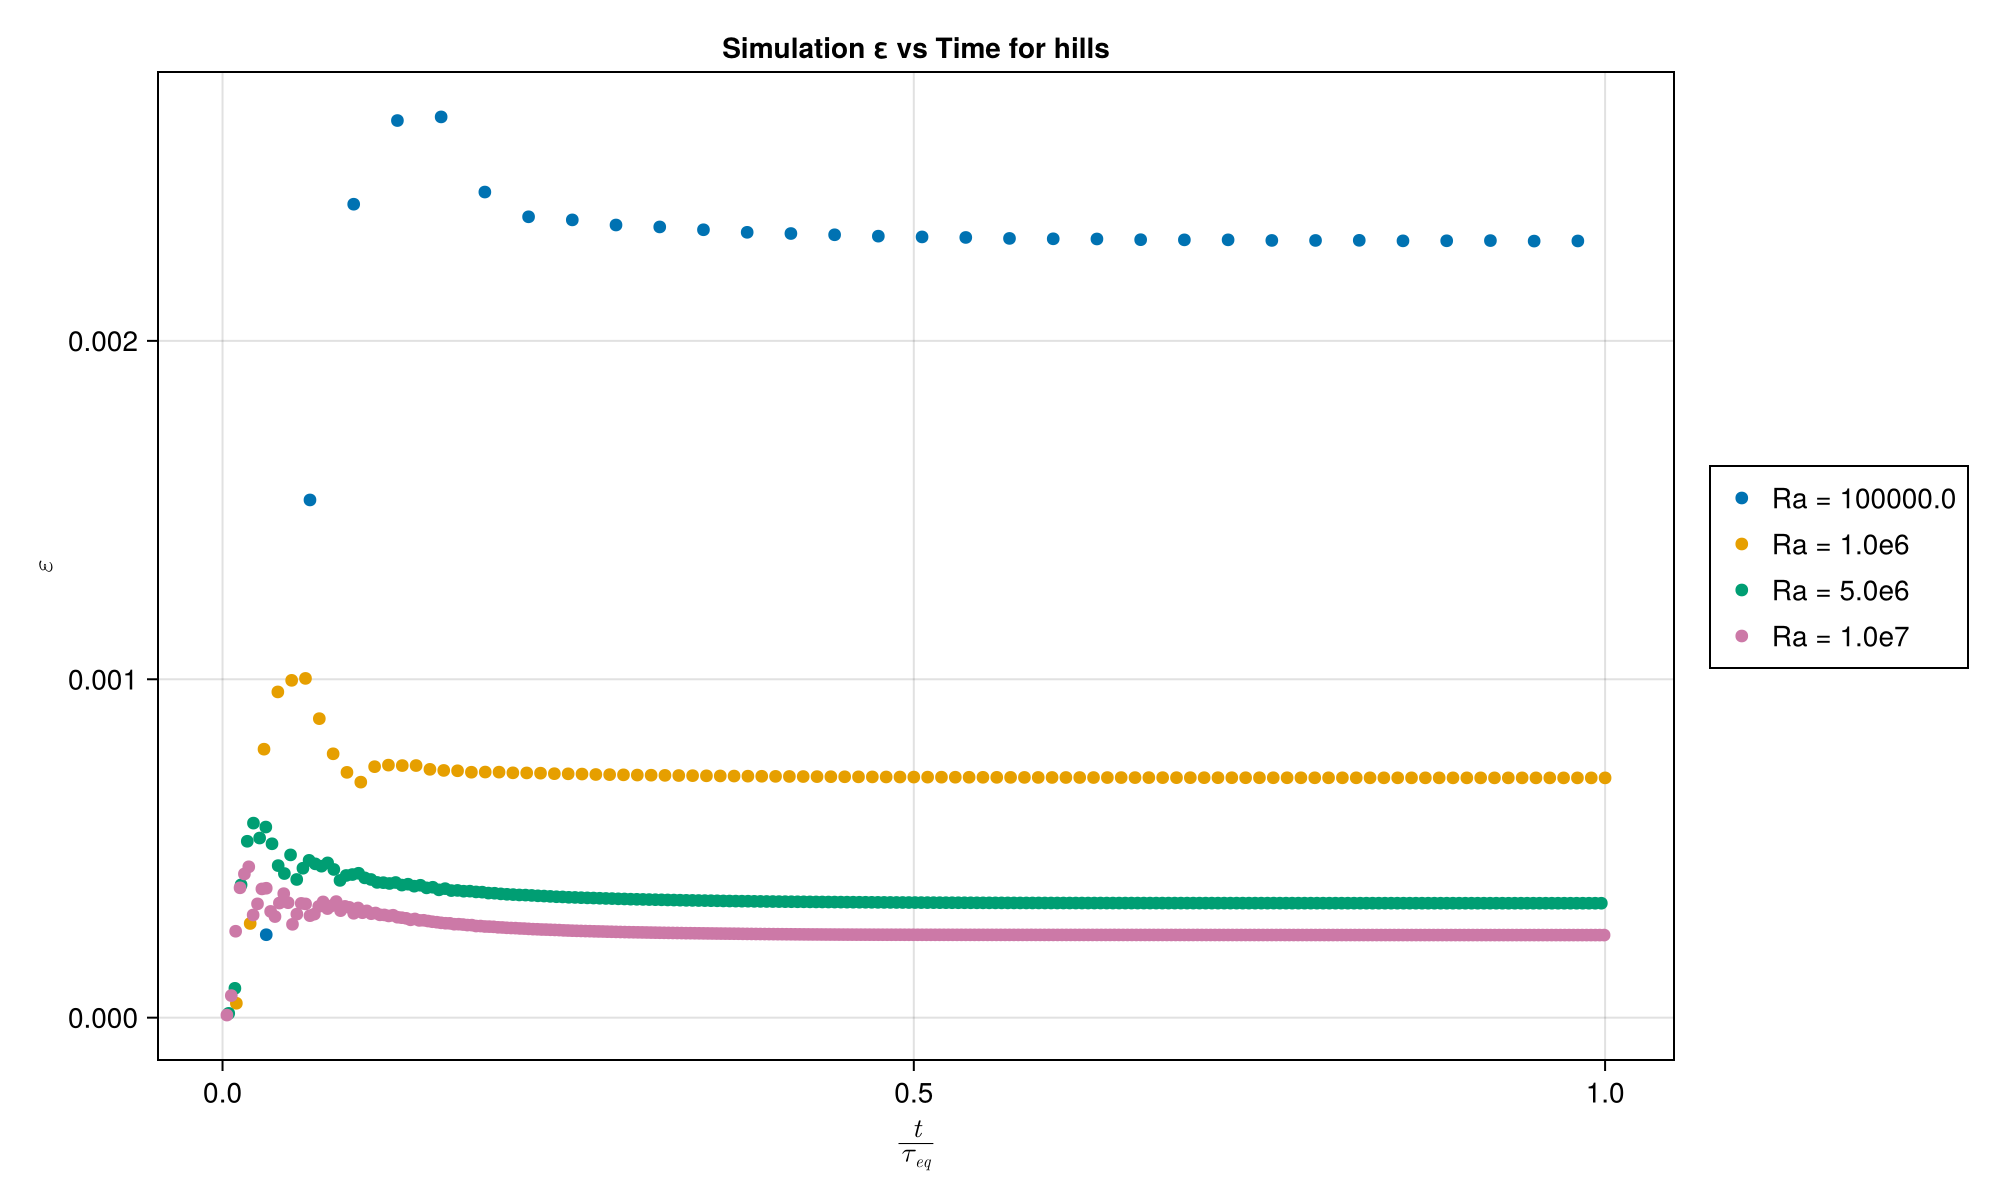

In [24]:
f_hills_2 = Figure(size=(1000, 600))
ax_hills_2 = Axis(f_hills_2[1, 1], xlabel=L"\frac{t}{\tau_{eq}}", ylabel=L"\varepsilon", title="Volume Averaged ε vs Time for hills")
for ds in list_hill_datasets
    plot_avg(ax_hills_2, ds, "ε")
end
Legend(f_hills_2[1, 2], ax_hills_2)
f_hills_2

In [1]:
f_ε_scatter_hill = Figure(size = (800, 500))
ax_ε_scatter_hill = Axis(f_ε_scatter_hill[1, 1], 
    xscale = log10, 
    yscale = log10,
    xlabel=L"\text{Rayleigh Number} (Ra)", 
    ylabel=L"\text{Time Averaged (equilibrated)} \varepsilon", 
    title=L"\text{Mean } \varepsilon \text{ vs } Ra \text{ for hill simulations}")

Ra_vals = Float64[]
ε_means_hill = Float64[]
ε_theories_from_sim_hill = Float64[]
ε_theories_from_brain_hill = Float64[]

for ds in list_hill_datasets
    Ra = ds.attrib["Ra"]
    ν = ds.attrib["ν"]
    H = ds.attrib["H"]
    ε_mean = dissipation_analysis(ds, "ε")[3] ./ (ν^3 / H^4) # nondimensionalize ε_mean
    ε_sim_theory = dissipation_analysis(ds, "ε")[1] ./ (ν^3 / H^4) # nondimensionalize ε_sim_theory

    push!(Ra_vals, Ra)
    push!(ε_means_hill, ε_mean)
    push!(ε_theories_from_brain_hill, 2 *(Ra))
    push!(ε_theories_from_sim_hill, ε_sim_theory)
end


#plot the scatter points
scatter!(ax_ε_scatter_hill, Ra_vals, ε_means_hill, label="Simulation ε", markersize=8)
#theoretical prediction curve
lines!(ax_ε_scatter_hill, Ra_vals, ε_theories_from_brain_hill, label="Theoretical ε Curve (Simplified)", linewidth=8, color=:orange)
lines!(ax_ε_scatter_hill, Ra_vals, ε_theories_from_brain_hill .* 0.1, label="0.1 Times Theoretical ε Prediction", alpha=0.5, color=:purple)
lines!(ax_ε_scatter_hill, Ra_vals, ε_theories_from_brain_hill .* 0.5, label="0.5 Times Theoretical ε Prediction", alpha=0.5, color=:darkgreen)
lines!(ax_ε_scatter_hill, Ra_vals, ε_theories_from_sim_hill, label = "Theoretical ε from Simulation Parameters")

Legend(f_ε_scatter_hill[1, 2], ax_ε_scatter_hill)
f_ε_scatter_hill



UndefVarError: UndefVarError: `Figure` not defined in `Main`
Suggestion: check for spelling errors or missing imports.